In [1]:
RUN_ALL_EXPERIMENTS = True

In [2]:
!python --version
!pip --version
# !pip list

Python 3.12.13
pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)


## Set up and Import libraries

In [3]:
!pip install openpyxl # For read excel format. TPU only
!pip install pyvi # For Vietnamese word_segment
!pip install emoji
!pip install gensim
!pip install torch
!pip install transformers==4.52.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.4 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 whic

### Library

In [4]:
import pandas as pd
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel, AutoConfig, get_scheduler # AutoModelForSequenceClassification, BertForSequenceClassification
from torch.optim import AdamW
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
import re
from tqdm import tqdm
import time
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix
import pickle

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [ ]:
# STEP 0 - Generate A4 averaged artifact from existing seeds only.
# This cell never trains. It averages three saved test probability bundles and uses
# validation-fitted thresholds when available; it never tunes thresholds on test.
import os
import json
import numpy as np
from sklearn.metrics import f1_score, classification_report

def _find_artifact_root():
    candidates = [
        "/kaggle/input/vigoemo-artifacts",
        os.path.join(WORKING_DIR, "artifacts") if "WORKING_DIR" in globals() else "artifacts",
    ]
    for root in candidates:
        if root and os.path.exists(os.path.join(root, "ASL_Emoji_CB__seed42", "test_probs.npy")):
            return root
    for input_root in ["/kaggle/input", "/kaggle/input/datasets"]:
        if not os.path.isdir(input_root):
            continue
        for current_root, dirs, files in os.walk(input_root):
            if os.path.exists(os.path.join(current_root, "ASL_Emoji_CB__seed42", "test_probs.npy")):
                return current_root
    raise FileNotFoundError("Could not find vigoemo-artifacts with ASL_Emoji_CB__seed42/test_probs.npy")

def _find_optimal_thresholds_per_class_a4(probs, targets, grid=None, min_support=10, lo=0.1, hi=0.9, default=0.5):
    if grid is None:
        grid = np.arange(0.1, 0.901, 0.01)
    best_t = np.full(probs.shape[1], default, dtype=float)
    for c in range(probs.shape[1]):
        if targets[:, c].sum() < min_support:
            continue
        best_f1 = -1.0
        for t in grid:
            f1 = f1_score(targets[:, c], (probs[:, c] >= t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_t[c] = f1, t
        best_t[c] = float(np.clip(best_t[c], lo, hi))
    return best_t

def _load_thresholds_for_a4(seed42_dir, labels=None):
    val_probs_path = os.path.join(seed42_dir, "val_probs.npy")
    val_targets_path = os.path.join(seed42_dir, "val_targets.npy")
    if os.path.exists(val_probs_path) and os.path.exists(val_targets_path):
        val_probs = np.load(val_probs_path)
        val_targets = np.load(val_targets_path).astype(int)
        thresholds_arr = _find_optimal_thresholds_per_class_a4(val_probs, val_targets)
        if labels is None:
            labels = [f"class_{i}" for i in range(val_probs.shape[1])]
        return {labels[i]: float(thresholds_arr[i]) for i in range(len(labels))}

    thresholds_path = os.path.join(seed42_dir, "thresholds.json")
    if os.path.exists(thresholds_path):
        with open(thresholds_path, "r", encoding="utf-8") as f:
            return {k: float(v) for k, v in json.load(f).items()}

    raise FileNotFoundError(
        "No seed42 val_probs/val_targets or thresholds.json found. Refusing to tune on test."
    )

def generate_a4_artifact():
    artifact_root = _find_artifact_root()
    seed42_dir = os.path.join(artifact_root, "ASL_Emoji_CB__seed42")
    p42 = np.load(os.path.join(seed42_dir, "test_probs.npy"))
    p1 = np.load(os.path.join(artifact_root, "ASL_Emoji_CB_ensemble_seed1", "test_probs.npy"))
    p7 = np.load(os.path.join(artifact_root, "ASL_Emoji_CB_ensemble_seed7", "test_probs.npy"))
    targets = np.load(os.path.join(seed42_dir, "test_targets.npy")).astype(int)
    avg_probs = (p42 + p1 + p7) / 3.0

    labels = list(label_dict.values()) if "label_dict" in globals() else None
    thresholds = _load_thresholds_for_a4(seed42_dir, labels=labels)
    label_order = labels if labels is not None else list(thresholds.keys())
    threshold_arr = np.array([thresholds[c] for c in label_order], dtype=float)
    preds = (avg_probs >= threshold_arr.reshape(1, -1)).astype(int)
    mf1 = f1_score(targets, preds, average="macro", zero_division=0)

    output_root = WORKING_DIR if "WORKING_DIR" in globals() else ("/kaggle/working" if os.path.isdir("/kaggle") else ".")
    out_dir = os.path.join(output_root, "artifacts", "A4")
    os.makedirs(out_dir, exist_ok=True)
    np.save(os.path.join(out_dir, "test_probs.npy"), avg_probs)
    np.save(os.path.join(out_dir, "test_targets.npy"), targets)
    with open(os.path.join(out_dir, "thresholds.json"), "w", encoding="utf-8") as f:
        json.dump(thresholds, f, indent=2, ensure_ascii=False)
    with open(os.path.join(out_dir, "classification_report.txt"), "w", encoding="utf-8") as f:
        f.write(classification_report(targets, preds, target_names=label_order, zero_division=0))

    print(f"A4 artifact OK — MF1 = {mf1:.4f}")
    return avg_probs, targets, thresholds, mf1

# Run once labels/paths are available. If this cell is executed too early, call
# generate_a4_artifact() again after the label setup cells.
try:
    A4_avg_probs, A4_targets, A4_thresholds, A4_mf1 = generate_a4_artifact()
except Exception as exc:
    print(f"A4 artifact generation deferred: {exc}")


In [5]:
# Check GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# # Check for TPU
# try:
#     import torch_xla
#     import torch_xla.core.xla_model as xm
#     device = xm.xla_device()
# except ImportError:
#     # Check for GPU
#     if torch.cuda.is_available():
#         device = torch.device('cuda')
#     # Default to CPU
#     else:
#         device = torch.device('cpu')
print('Device:', device)
# EPOCHS = 6
# N_SPLITS = 10

Device: cuda:0


## Load Data

In [6]:
import os
import pandas as pd

def _has_vigoemotion_files(root):
    return all(os.path.exists(os.path.join(root, name)) for name in ["train.csv", "val.csv", "test.csv"]) and os.path.exists(os.path.join(root, "docs", "label_dict.json"))

def _find_data_root():
    candidates = [
        "/kaggle/input/visoemotion/ViGoEmotions_Reproduce/ViGoEmotions_Reproduce/ViGoEmotions",
        "/kaggle/input/ViGoEmotions_Reproduce/ViGoEmotions_Reproduce/ViGoEmotions",
        os.path.join(os.getcwd(), "data", "ViGoEmotions"),
    ]
    for candidate in candidates:
        if os.path.isdir(candidate) and _has_vigoemotion_files(candidate):
            return candidate
    for input_root in ["/kaggle/input", "/kaggle/input/datasets"]:
        if not os.path.isdir(input_root):
            continue
        for current_root, dirs, files in os.walk(input_root):
            if _has_vigoemotion_files(current_root):
                return current_root
    raise FileNotFoundError("Could not find ViGoEmotions data root. Attach the visoemotion Kaggle dataset, then rerun this cell.")

DATA_ROOT = _find_data_root()
print(f"Resolved DATA_ROOT: {DATA_ROOT}")
CHECKPOINT_INPUT_DIR = os.path.join(DATA_ROOT, "checkpoints")
WORKING_DIR = "/kaggle/working"
CHECKPOINT_DIR = os.path.join(WORKING_DIR, "checkpoints")
REPORT_DIR = os.path.join(WORKING_DIR, "reports")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
repo_root = DATA_ROOT

print("Current working directory:")
!pwd

print("\nCheck repo root:")
print(os.listdir(repo_root))

print("\nCheck corpus:")
print(os.listdir(os.path.join(repo_root, "corpus")))

docs_root = os.path.join(repo_root, "model", "docs")
print("\nCheck model/docs:")
print(os.listdir(docs_root))

# Kiểm tra dataset CSV đọc được không
train_df = pd.read_csv(os.path.join(repo_root, "corpus", "train.csv"))
val_df = pd.read_csv(os.path.join(repo_root, "corpus", "val.csv"))
test_df = pd.read_csv(os.path.join(repo_root, "corpus", "test.csv"))

print("\nDataset shapes:")
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

expected_rows = {"Train": 16531, "Val": 2066, "Test": 2067}
actual_rows = {"Train": len(train_df), "Val": len(val_df), "Test": len(test_df)}
assert actual_rows == expected_rows, f"Unexpected dataset split sizes: {actual_rows}"
print("Verified split row counts:", actual_rows)

print("\nColumns:")
print(train_df.columns)

train_df.head()


Current working directory:
/kaggle/working

Check repo root:
['reports', 'model', 'checkpoints', 'README.md', 'emoji2vec.bin', 'annotation', 'docs', 'corpus', '.git']

Check corpus:
['val.csv', 'dataset_visobert.pkl', 'label_dict.json', 'dataset_V1.xlsx', 'train.csv', 'test.csv']

Check model/docs:
['teencode4.txt', 'emojis.json', 'patterns.json', 'label_dict.json']

Dataset shapes:
Train: (16531, 3)
Val: (2066, 3)
Test: (2067, 3)
Verified split row counts: {'Train': 16531, 'Val': 2066, 'Test': 2067}

Columns:
Index(['id', 'text', 'labels'], dtype='object')


,id,text,labels
0,tik000008,Xem mà ngẫm lại cuộc đời bản thân ta đã trải q...,[12]
1,5743,bức ảnh xuất sắc ❤️,"[2, 8, 3]"
2,32895,"Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố là...","[8, 7]"
3,you001182,"Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi...",[27]
4,12052,Dima Egiazarov bởi vì chúng tôi là người Việt ...,"[24, 23]"


In [ ]:
import emoji
from gensim.models import KeyedVectors
import torch.nn.functional as F

def extract_emoji_sequence(text):
    text = str(text)
    if hasattr(emoji, 'emoji_list'):
        return [item['emoji'] for item in emoji.emoji_list(text)]
    return [ch for ch in text if ch in emoji.EMOJI_DATA]

# Keep extract_emojis alias for compatibility
extract_emojis = extract_emoji_sequence

def load_emoji2vec(path=os.path.join(DATA_ROOT, 'emoji2vec.bin')):
    return KeyedVectors.load_word2vec_format(str(path), binary=True)

class EmojiEncoder(nn.Module):
    def __init__(self, e2v, dim=300):
        super().__init__()
        self.dim = dim
        self.emoji_dict = {}
        if e2v is not None:
            for word in e2v.index_to_key:
                self.emoji_dict[word] = torch.tensor(e2v[word], dtype=torch.float32)

    def forward(self, emoji_ids, device=None):
        if device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        batch_vectors = []
        for sample_emojis in emoji_ids:
            sample_vectors = []
            for emo in sample_emojis:
                if emo == '':
                    continue
                if emo in self.emoji_dict:
                    sample_vectors.append(self.emoji_dict[emo].to(device))
                else:
                    sample_vectors.append(torch.zeros(self.dim, device=device))
            if not sample_vectors:
                batch_vectors.append(torch.zeros(self.dim, device=device))
            else:
                batch_vectors.append(torch.stack(sample_vectors).mean(dim=0))
        if not batch_vectors:
            return torch.empty((0, self.dim), device=device)
        return torch.stack(batch_vectors, dim=0)

class ViSoBertMultiLabel(nn.Module):
    def __init__(self, model_name='uitnlp/visobert', num_labels=28, dropout=0.2, use_emoji_branch=False, e2v=None, emoji_dim=300):
        super().__init__()
        self.model_name = model_name
        self.num_labels = num_labels
        self.use_emoji_branch = use_emoji_branch
        
        config = AutoConfig.from_pretrained(model_name)
        self.backbone = AutoModel.from_pretrained(model_name, config=config)
        hidden_size = getattr(config, 'hidden_size', None) or getattr(config, 'dim', None)
        if hidden_size is None:
            raise ValueError(f'Could not infer hidden size from config of {model_name}')
        self.hidden_size = hidden_size
        self.dropout = nn.Dropout(dropout)
        
        if self.use_emoji_branch:
            self.emoji_encoder = EmojiEncoder(e2v, dim=emoji_dim)
            self.classifier = nn.Linear(hidden_size + emoji_dim, num_labels)
        else:
            self.classifier = nn.Linear(hidden_size, num_labels)

    def encode(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        H = out.last_hidden_state
        m = attention_mask.unsqueeze(-1).float()
        return (H * m).sum(1) / m.sum(1).clamp(min=1e-9)

    def forward(self, input_ids, attention_mask, emoji_ids=None, emoji_vectors=None):
        h_cls = self.encode(input_ids, attention_mask)
        if self.use_emoji_branch:
            if emoji_vectors is not None:
                h_emoji = emoji_vectors.to(h_cls.device)
            elif emoji_ids is not None:
                h_emoji = self.emoji_encoder(emoji_ids, device=h_cls.device)
            else:
                h_emoji = torch.zeros(h_cls.size(0), self.emoji_encoder.dim, device=h_cls.device)
            if h_emoji.size(0) != h_cls.size(0):
                raise ValueError(
                    f'emoji batch size {h_emoji.size(0)} != text batch size {h_cls.size(0)}'
                )
            feat = torch.cat([h_cls, h_emoji], dim=1)
        else:
            feat = h_cls
        logits = self.classifier(self.dropout(feat))
        return {'logits': logits, 'cls_embedding': h_cls}

class EmojiAwareViSoBERT(nn.Module):
    def __init__(self, model_name='uitnlp/visobert', num_labels=28, emoji_dim=300, dropout=0.2, e2v=None):
        super().__init__()
        config = AutoConfig.from_pretrained(
            model_name,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1,
        )
        self.bert = AutoModel.from_pretrained(model_name, config=config)
        hidden_size = getattr(config, 'hidden_size', None) or getattr(config, 'dim', None)
        if hidden_size is None:
            raise ValueError(f'Could not infer hidden size from config of {model_name}')
        self.hidden_size = hidden_size
        
        self.emoji_projection = nn.Sequential(
            nn.Linear(emoji_dim, hidden_size),
            nn.GELU(),
            nn.LayerNorm(hidden_size),
        )
        self.fusion = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_labels),
        )
        self.emoji_encoder = EmojiEncoder(e2v, dim=emoji_dim)

    def encode_text(self, input_ids, attention_mask):
        out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
        H = out.last_hidden_state
        m = attention_mask.unsqueeze(-1).float()
        return (H * m).sum(1) / m.sum(1).clamp(min=1e-9)

    def forward(self, input_ids, attention_mask, emoji_ids=None, emoji_vectors=None):
        h_text = self.encode_text(input_ids=input_ids, attention_mask=attention_mask)
        
        if emoji_vectors is None and emoji_ids is not None:
            emoji_vectors = self.emoji_encoder(emoji_ids, device=h_text.device)
            
        if emoji_vectors is None:
            device = h_text.device
            emoji_vectors = torch.zeros(h_text.size(0), self.emoji_encoder.dim, device=device)
            
        h_emoji = self.emoji_projection(emoji_vectors.float())
        logits = self.fusion(torch.cat([h_text, h_emoji], dim=1))
        return {'logits': logits, 'cls_embedding': h_text}


class EmojiCrossAttention(nn.Module):
    def __init__(self, emoji_init_matrix, hidden=768, n_heads=8, K=8):
        super().__init__()
        self.K = K
        self.emb = nn.Embedding.from_pretrained(
            emoji_init_matrix.float(), freeze=False, padding_idx=0
        )
        self.proj = nn.Sequential(
            nn.Linear(emoji_init_matrix.shape[1], hidden),
            nn.GELU(),
            nn.LayerNorm(hidden),
        )
        self.pos_emb = nn.Embedding(K, hidden)
        self.attn = nn.MultiheadAttention(hidden, n_heads, batch_first=True)
        self.gate = nn.Linear(hidden, 1)

    def forward(self, h_text, emoji_ids, emoji_mask):
        B, K = emoji_ids.shape
        e = self.proj(self.emb(emoji_ids))
        pos = self.pos_emb(torch.arange(K, device=e.device))
        e = e + pos.unsqueeze(0)
        has_emoji = emoji_mask.bool().any(dim=1)
        key_padding_mask = (emoji_mask == 0)
        safe_key_padding_mask = key_padding_mask.clone()
        safe_key_padding_mask[~has_emoji] = False
        q = h_text.unsqueeze(1)
        attn_out, _ = self.attn(q, e, e, key_padding_mask=safe_key_padding_mask)
        attn_out = attn_out.squeeze(1)
        has_emoji_f = has_emoji.float().unsqueeze(1)
        attn_out = attn_out * has_emoji_f
        g = torch.sigmoid(self.gate(attn_out)) * has_emoji_f
        return h_text + g * attn_out


class LabelGraphHead(nn.Module):
    def __init__(self, A_cooc, hidden=768, d=256, n_labels=28):
        super().__init__()
        self.d = d
        self.label_emb = nn.Embedding(n_labels, d)
        self.proj = nn.Linear(hidden, d)
        self.context_proj = nn.Linear(hidden, d)
        self.gat1 = nn.Linear(d, d)
        self.gat2 = nn.Linear(d, d)
        self.edge_residual = nn.Parameter(torch.zeros(n_labels, n_labels))
        self.register_buffer("A_cooc", A_cooc.float())
        self.logit_bias = nn.Parameter(torch.zeros(n_labels))

    def forward(self, H_seq, attention_mask, h_emoji=None):
        H = self.proj(H_seq)
        L = self.label_emb.weight
        scores = (H @ L.T).permute(0, 2, 1) / (self.d ** 0.5)
        mask = (attention_mask == 0).unsqueeze(1)
        scores = scores.masked_fill(mask, -1e9)
        attn = torch.softmax(scores, dim=-1)
        R = attn @ H
        if h_emoji is not None:
            R = R + self.context_proj(h_emoji).unsqueeze(1)
        A = self.A_cooc + self.edge_residual.clamp(-0.1, 0.1)
        R1 = F.gelu(self.gat1(torch.einsum("ij,bjd->bid", A, R)))
        R2 = F.gelu(self.gat2(torch.einsum("ij,bjd->bid", A, R1))) + R
        logits = (R2 * L.unsqueeze(0)).sum(-1) + self.logit_bias
        return logits, R2


class EmojiLabelGraphViSoBERT(nn.Module):
    def __init__(self, model_name, emoji_init_matrix, A_cooc=None, n_labels=28,
                 use_emoji_attn=True, use_label_graph=True, dropout=0.2):
        super().__init__()
        config = AutoConfig.from_pretrained(
            model_name,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1,
        )
        self.backbone = AutoModel.from_pretrained(model_name, config=config)
        hidden = getattr(config, "hidden_size", None) or getattr(config, "dim", None)
        if hidden is None:
            raise ValueError(f"Could not infer hidden size from config of {model_name}")
        self.hidden_size = hidden
        self.use_emoji_attn = use_emoji_attn
        self.use_label_graph = use_label_graph
        self.dropout = nn.Dropout(dropout)
        if self.use_emoji_attn:
            self.emoji_attn = EmojiCrossAttention(emoji_init_matrix, hidden=hidden, n_heads=8, K=EMOJI_K)
        else:
            self.emoji_attn = None
        if self.use_label_graph:
            if A_cooc is None:
                raise ValueError("A_cooc is required when use_label_graph=True")
            self.label_graph_head = LabelGraphHead(A_cooc, hidden=hidden, d=256, n_labels=n_labels)
            self.classifier = None
        else:
            self.label_graph_head = None
            self.classifier = nn.Linear(hidden, n_labels)
        self.emotional_head = nn.Linear(hidden, 1)

    def encode_text(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        H = out.last_hidden_state
        m = attention_mask.unsqueeze(-1).float()
        h_text = (H * m).sum(1) / m.sum(1).clamp(min=1e-9)
        return H, h_text

    def forward(self, input_ids, attention_mask, emoji_ids=None, emoji_mask=None):
        H_seq, h_text = self.encode_text(input_ids, attention_mask)
        h_fused = h_text
        if self.use_emoji_attn:
            if emoji_ids is None or emoji_mask is None:
                B = input_ids.size(0)
                emoji_ids = torch.zeros(B, EMOJI_K, dtype=torch.long, device=input_ids.device)
                emoji_mask = torch.zeros(B, EMOJI_K, dtype=torch.long, device=input_ids.device)
            h_fused = self.emoji_attn(h_text, emoji_ids, emoji_mask)
        if self.use_label_graph:
            logits, _ = self.label_graph_head(H_seq, attention_mask, h_emoji=h_fused)
        else:
            logits = self.classifier(self.dropout(h_fused))
        emotional_logit = self.emotional_head(h_fused)
        return {"logits": logits, "cls_embedding": h_fused, "emotional_logit": emotional_logit}


In [8]:
train_df.info()
val_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16531 entries, 0 to 16530
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      16531 non-null  object
 1   text    16531 non-null  object
 2   labels  16531 non-null  object
dtypes: object(3)
memory usage: 387.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2066 entries, 0 to 2065
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2066 non-null   object
 1   text    2066 non-null   object
 2   labels  2066 non-null   object
dtypes: object(3)
memory usage: 48.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2067 entries, 0 to 2066
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2067 non-null   object
 1   text    2067 non-null   object
 2   labels  2067 non-null   object
dtypes: object(3)
memory usage: 48.6+ KB


In [9]:
# train_df = train_df[:128]
# val_df = val_df[:64]
# test_df = test_df[:64]

### Pre-processing text

In [10]:
# Load normalization dictionaries robustly
import json
import os
import re

docs_paths = []
if 'repo_root' in globals():
    docs_paths.append(os.path.join(repo_root, 'docs'))
    docs_paths.append(os.path.join(repo_root, 'model', 'docs'))
if 'DATA_ROOT' in globals():
    docs_paths.append(os.path.join(DATA_ROOT, 'docs'))
    docs_paths.append(os.path.join(DATA_ROOT, 'model', 'docs'))
docs_paths.extend(['docs', '../docs'])

pattern_dict = None
emoji_dict = None
teen_dict = None

for doc_dir in docs_paths:
    patterns_path = os.path.join(doc_dir, 'patterns.json')
    emojis_path = os.path.join(doc_dir, 'emojis.json')
    teencode_path = os.path.join(doc_dir, 'teencode4.txt')
    
    if os.path.exists(patterns_path) and os.path.exists(emojis_path) and os.path.exists(teencode_path):
        with open(patterns_path, 'r', encoding='utf-8') as f:
            pattern_dict = json.load(f)
        with open(emojis_path, 'r', encoding='utf-8') as f:
            emoji_dict = json.load(f)
        with open(teencode_path, 'r', encoding='utf-8') as f:
            content = f.read()
            lines = content.split('\n')
            teen_dict = {}
            for line in lines:
                if line.strip():
                    elements = line.split('\t')
                    if len(elements) >= 2:
                        teen_dict[elements[0]] = elements[1]
        print(f"Loaded dictionaries successfully from: {doc_dir}")
        break

if pattern_dict is None or emoji_dict is None or teen_dict is None:
    raise FileNotFoundError("Could not find patterns.json, emojis.json, or teencode4.txt in any of the search paths.")

text = 'T thích :)))) =))))) =]]]] :>> ==== :::::: ????? !!!!!! thì t cứ :) thôi'
for pattern, replacement in pattern_dict.items():
    text = re.sub(pattern, replacement, text)
print(text)
# Preprocessing flag
is_preprocessing = True

# Set path alias for downstream cells that reference 'path'
path = DATA_ROOT

# Keep a copy of the original text for the Emoji2Vec branch before preprocessing
for df in [train_df, val_df, test_df]:
    if 'original_text' not in df.columns:
        df['original_text'] = df['text'].astype(str)


Loaded dictionaries successfully from: /kaggle/input/datasets/nhatphatnguyen/visoemotion/ViGoEmotions_Reproduce/ViGoEmotions_Reproduce/ViGoEmotions/docs
T thích :)) =)) =]] :> = : ? ! thì t cứ :) thôi


In [11]:

def normalize_pattern(text):
    """:)))) -> :))"""
    for pattern, replacement in pattern_dict.items():
        text = re.sub(pattern=pattern, repl=replacement, string=text)

    return text


def remove_duplicate_chars(text):
    """Apply for alphabet only. Ex: cườiiiiii -> cười"""
    prev_char = None
    result = []
    for char in text:
        if char.isalpha() and prev_char == char:
            continue
        prev_char = char
        result.append(char)
    return ''.join(result)


def remove_duplicate_emoji(text):
    """😄😄😄😄 -> 😄"""
    result = []
    prev_emoji = None
    for char in text:
        if char in emoji.EMOJI_DATA:
            if char == prev_emoji:
                continue
            prev_emoji = char
        else:
            prev_emoji = None
        result.append(char)
    return ''.join(result)


def replace_teencode(text):
    """
    :param text:
    :return:
    """
    # for teen, normal in teen_dict.items():
    #     text = text.replace(teen, normal)
    # return text
    for old_word, new_word in teen_dict.items():
        pattern = re.compile(r'\b{}\b'.format(re.escape(old_word)))
        text = pattern.sub(new_word, text)
    return text


def replacing_emojis(text):
    for emoji, replacement in emoji_dict.items():
        text = text.replace(emoji, ' ' + replacement + ' ')
    return text


def clean_text(text):
    text = text.lower()
    text = normalize_pattern(text)
    text = remove_duplicate_chars(text)
    text = remove_duplicate_emoji(text)
    text = replace_teencode(text)
    text = replacing_emojis(text)

    # remove new line char '\n'
    text = re.sub(r'(?<![.,!?;:])\n', r'. ', text)  # Replace newline with period and space if no punctuation. (1st priority)
    text = re.sub(r'\n([.,!?;:])?', r' \1', text)  # Replace newline with punctuation if present (2nd step)

    # Add spaces around punctuation marks, except in cases like 'X.Y'. This step must after new line processing.
    punctuation = r'([.,!?;:])'
    # text = re.sub(r'(?<![A-Z])' + punctuation + r'(?![A-Z])', r' \1 ', text) # except patterns like 'X.X.X'
    text = re.sub(punctuation, r' \1 ', text)  # no exceptions

    # remove extra spaces ('\s', '\n', '\t')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print(clean_text(':)))))))'))
print(clean_text('Bao kỉ niệm lại ùa về nguyên vẹn.nhớ quá.... y.ê.u'))


cười_lớn
bao kỉ niệm lại ùa về nguyên vẹn . nhớ quá . . . y . ê . u


In [12]:
if is_preprocessing == True:
    for df in [train_df, val_df, test_df]:
        if 'original_text' not in df.columns:
            df['original_text'] = df['text'].astype(str)
    train_df['clean_text'] = train_df['text'].apply(clean_text)
    val_df['clean_text'] = val_df['text'].apply(clean_text)
    test_df['clean_text'] = test_df['text'].apply(clean_text)
    display(train_df.head())

,id,text,labels,original_text,clean_text
0,tik000008,Xem mà ngẫm lại cuộc đời bản thân ta đã trải q...,[12],Xem mà ngẫm lại cuộc đời bản thân ta đã trải q...,xem mà ngẫm lại cuộc đời bản thân ta đã trải q...
1,5743,bức ảnh xuất sắc ❤️,"[2, 8, 3]",bức ảnh xuất sắc ❤️,bức ảnh xuất sắc trái_tim
2,32895,"Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố là...","[8, 7]","Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố là...","vừa đẹp trai , vừa tài giỏi . nhà mặt phố , bố..."
3,you001182,"Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi...",[27],"Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi...","bài học : . 1 : 5 nhìn , 4 chạm , 3 nghe , 2 n..."
4,12052,Dima Egiazarov bởi vì chúng tôi là người Việt ...,"[24, 23]",Dima Egiazarov bởi vì chúng tôi là người Việt ...,dima egiazarov bởi vì chúng tôi là người việt ...


In [13]:
# Relace 'text' col by 'clean_text' col
if is_preprocessing == True:
    for df in [train_df, val_df, test_df]:
        if  'text' in df.columns and 'clean_text' in df.columns:
            df['text'] = df['clean_text']
            df.drop(columns=['clean_text'], inplace=True, errors='ignore') # ignore if 'clean_text' does not exist
    display(train_df)

,id,text,labels,original_text
0,tik000008,xem mà ngẫm lại cuộc đời bản thân ta đã trải q...,[12],Xem mà ngẫm lại cuộc đời bản thân ta đã trải q...
1,5743,bức ảnh xuất sắc trái_tim,"[2, 8, 3]",bức ảnh xuất sắc ❤️
2,32895,"vừa đẹp trai , vừa tài giỏi . nhà mặt phố , bố...","[8, 7]","Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố là..."
3,you001182,"bài học : . 1 : 5 nhìn , 4 chạm , 3 nghe , 2 n...",[27],"Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi..."
4,12052,dima egiazarov bởi vì chúng tôi là người việt ...,"[24, 23]",Dima Egiazarov bởi vì chúng tôi là người Việt ...
...,...,...,...,...
16526,768,tự dưng cay mẹ mắt,[21],tự dưng cay mẹ mắt
16527,1983,per đã nhẫn nhịn lắm . . . đến khi con sen tao...,"[0, 10, 2]",per đã nhẫn nhịn lắm ... đến khi con sen tao c...
16528,18199,"trời ơi , xem tin hôm qua giờ mà không biết là...","[13, 21, 6]","Trời ơi, xem tin hôm qua giờ mà không biết là ..."
16529,tik011747,nếu có thể quay lại tôi thề ngày hôm ấy tôi sẽ...,"[18, 4]",Nếu có thể quay lại tôi thề ngày hôm ấy tôi sẽ...


In [14]:
# Cleaned splits remain in memory for this experiment.
# Do not export or reload an Excel dataset; train/val/test come directly from the provided CSV files.
print('Cleaned CSV splits kept in memory; original_text preserved for the emoji branch.')

Cleaned CSV splits kept in memory; original_text preserved for the emoji branch.


In [15]:
# Verify emoji extraction: original_text should contain emojis,
# preprocessed text column should have ~0% (emojis replaced by Vietnamese words).
import emoji as _emoji_lib

def count_emoji_samples(series):
    return sum(1 for t in series if any(ch in _emoji_lib.EMOJI_DATA for ch in str(t)))

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    n_orig = count_emoji_samples(df['original_text'])
    n_clean = count_emoji_samples(df['text'])
    print(f'{name}: {n_orig}/{len(df)} ({100*n_orig/len(df):.1f}%) samples have emojis in original_text')
    print(f'{name}: {n_clean}/{len(df)} ({100*n_clean/len(df):.1f}%) samples have emojis in text (should be ~0%)')

assert count_emoji_samples(train_df['original_text']) > 0, 'BUG: no emojis found in original_text!'
print('\nEmoji extraction source verified: original_text preserves raw emojis.')

train: 4054/16531 (24.5%) samples have emojis in original_text
train: 84/16531 (0.5%) samples have emojis in text (should be ~0%)
val: 499/2066 (24.2%) samples have emojis in original_text
val: 10/2066 (0.5%) samples have emojis in text (should be ~0%)
test: 529/2067 (25.6%) samples have emojis in original_text
test: 14/2067 (0.7%) samples have emojis in text (should be ~0%)

Emoji extraction source verified: original_text preserves raw emojis.


In [16]:
train_texts = train_df['text'].tolist()
train_labels = train_df['labels'].tolist()
print(train_texts[0])
print(train_labels[0])

xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng
[12]


### Encode label

In [17]:
# Load label dict
with open(os.path.join(path, 'model', 'docs', 'label_dict.json'), 'r') as f:
    label_dict = json.load(f)

print("Number of labels:", len(label_dict))
print(label_dict)

Number of labels: 28
{'0': 'amusement', '1': 'excitement', '2': 'joy', '3': 'love', '4': 'desire', '5': 'optimism', '6': 'caring', '7': 'pride', '8': 'admiration', '9': 'gratitude', '10': 'relief', '11': 'approval', '12': 'realization', '13': 'surprise', '14': 'curiosity', '15': 'confusion', '16': 'fear', '17': 'nervousness', '18': 'remorse', '19': 'embarrassment', '20': 'disappointment', '21': 'sadness', '22': 'grief', '23': 'disgust', '24': 'anger', '25': 'annoyance', '26': 'disapproval', '27': 'neutral'}


In [18]:
label_to_idx = {label:int(idx) for idx, label in label_dict.items()}
idx_to_label = {int(idx):label for idx, label in label_dict.items()}
print(label_to_idx)
print(idx_to_label)

{'amusement': 0, 'excitement': 1, 'joy': 2, 'love': 3, 'desire': 4, 'optimism': 5, 'caring': 6, 'pride': 7, 'admiration': 8, 'gratitude': 9, 'relief': 10, 'approval': 11, 'realization': 12, 'surprise': 13, 'curiosity': 14, 'confusion': 15, 'fear': 16, 'nervousness': 17, 'remorse': 18, 'embarrassment': 19, 'disappointment': 20, 'sadness': 21, 'grief': 22, 'disgust': 23, 'anger': 24, 'annoyance': 25, 'disapproval': 26, 'neutral': 27}
{0: 'amusement', 1: 'excitement', 2: 'joy', 3: 'love', 4: 'desire', 5: 'optimism', 6: 'caring', 7: 'pride', 8: 'admiration', 9: 'gratitude', 10: 'relief', 11: 'approval', 12: 'realization', 13: 'surprise', 14: 'curiosity', 15: 'confusion', 16: 'fear', 17: 'nervousness', 18: 'remorse', 19: 'embarrassment', 20: 'disappointment', 21: 'sadness', 22: 'grief', 23: 'disgust', 24: 'anger', 25: 'annoyance', 26: 'disapproval', 27: 'neutral'}


In [19]:

def encode_labels(label, label_dict, num_classes=28, mode=None):
    """Converts a label string to a numerical representation.

    This function takes a label string and converts it into either a one-hot encoded vector or a list of label indices,
    depending on the specified mode.

    Args:
        label (str): The label string to encode. It can be a comma-separated string of numeric labels
                     (e.g., "[13, 20, 21, 0]") or a comma-separated string of string labels
                     (e.g., '["amusement", "desire", "embarrassment"]').
        label_dict (dict): A dictionary mapping label names (strings) to their corresponding indices (integers).
        num_classes (int, optional): The total number of classes. Defaults to 28.
        mode (str, optional): The encoding mode. Can be 'label' for label indices or 'one-hot' for one-hot encoding.
                              Defaults to 'one-hot'.

    Returns:
        np.ndarray or list: The encoded label representation. If `mode` is 'one-hot', it returns a one-hot encoded vector
                            as a NumPy array. If `mode` is 'label', it returns a list of label indices.

    Examples:
        >>> encode_labels("[13, 20, 21, 0]", idx_to_label)
        array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0])
        >>> encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx)
        array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
        >>> encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx, mode='label')
        [0, 13, 20]
    """
    labels = label.replace('[', '').replace(']', '').replace("'", '').replace('"', '').split(',')
    labels = [label.strip() for label in labels]
    # print(labels)
    if mode is None or mode == 'one-hot':
        label_vector = np.zeros(len(label_dict), dtype=int) # default: float64
        if labels[0].isnumeric(): # If input list is numeric labels
            labels = [int(label) for label in labels]
            for idx in label_dict.values():
                if idx in labels:
                    label_vector[idx] = 1
        elif not labels[0].isnumeric(): # If input list is string labels
            for label, idx in label_dict.items():
                if label in labels:
                    label_vector[idx] = 1
        return label_vector
    elif mode == 'label':
        labels = [label_dict[label] for label in labels]
        return labels



print('Ex1:', encode_labels("[13, 20, 21, 0]", label_to_idx))
print('Ex2:', encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx))
print('Ex3:', encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx, mode='label'))

Ex1: [1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
Ex2: [1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
Ex3: [0, 4, 19]


In [20]:
# Create train-val-test with one-hot encoding for labels.
# text = preprocessed text for ViSoBERT; original_text = raw text for emoji extraction.
train_texts = train_df['text'].tolist()
train_original_texts = train_df['original_text'].tolist()
train_labels = train_df['labels'].tolist()
train_labels = [encode_labels(label, label_to_idx) for label in train_labels]
print(train_texts[0])
print(train_original_texts[0])
print(train_labels[0])

val_texts = val_df['text'].tolist()
val_original_texts = val_df['original_text'].tolist()
val_labels = val_df['labels'].tolist()
val_labels = [encode_labels(label, label_to_idx) for label in val_labels]
print(val_texts[0])
print(val_original_texts[0])
print(val_labels[0])

test_texts = test_df['text'].tolist()
test_original_texts = test_df['original_text'].tolist()
test_labels = test_df['labels'].tolist()
test_labels = [encode_labels(label, label_to_idx) for label in test_labels]
print(test_texts[0])
print(test_original_texts[0])
print(test_labels[0])

xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng
Xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng
[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
buồn nốt tý dở thôi nha chảy_nước_mắt háo_hức
Buồn nốt tý dở thui nghen🥲🤩
[1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
không coi p1 đi xem p2 thì được không ta mai huệ
Ko coi p1 đi xem p2 thì đc ko ta Mai Huệ
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]


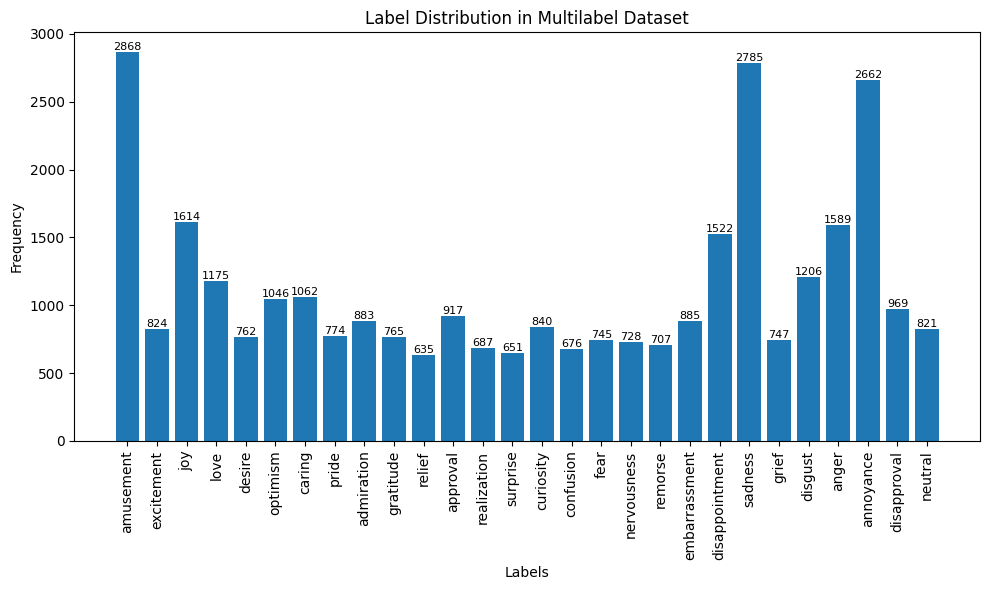

In [21]:
label_frequencies = np.sum(train_labels, axis=0) # calculate the frequency per label
label_names = list(label_dict.values())

plt.figure(figsize=(10, 6))
plt.bar(x=label_names, height=label_frequencies)
for x, y in zip(label_names, label_frequencies):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=8)

plt.xlabel('Labels')
plt.ylabel('Frequency')
plt.title('Label Distribution in Multilabel Dataset')
plt.xticks(rotation=90) # Rotate x-axis labels for readibility
plt.tight_layout() # adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
# STEP 1 - Co-occurrence label graph.
import numpy as np
import torch

def build_label_graph(train_labels, tau=0.4, p=0.25):
    L = np.stack(train_labels).astype(np.float32)
    count = L.sum(0)
    M = L.T @ L
    P = M / np.maximum(count[:, None], 1.0)
    A_bin = (P > tau).astype(np.float32)
    np.fill_diagonal(A_bin, 0.0)
    deg = A_bin.sum(1, keepdims=True)
    A = np.where(deg > 0, p * A_bin / np.maximum(deg, 1e-9), 0.0)
    A = A + (1.0 - p) * np.eye(L.shape[1], dtype=np.float32)
    A_neg_np = (P < 0.02).astype(np.float32)
    np.fill_diagonal(A_neg_np, 0.0)

    if not np.isfinite(A).all() or not np.isfinite(A_neg_np).all():
        raise ValueError("Label graph contains NaN/Inf.")

    labels = list(label_dict.values())
    off_diag = []
    for i in range(len(labels)):
        for j in range(len(labels)):
            if i != j:
                off_diag.append((float(P[i, j]), labels[i], labels[j]))
    off_diag.sort(reverse=True)
    print("Top-10 strongest P(j|i) label edges:")
    for score, src, dst in off_diag[:10]:
        print(f"  {src} -> {dst}: {score:.3f}")

    name_to_idx = {name: int(idx) for idx, name in label_dict.items()}
    for a, b in [("disappointment", "sadness"), ("anger", "annoyance"), ("amusement", "joy")]:
        ia, ib = name_to_idx.get(a), name_to_idx.get(b)
        ok = ia is not None and ib is not None and (A_bin[ia, ib] > 0 or A_bin[ib, ia] > 0)
        pa = P[ia, ib] if ia is not None and ib is not None else float("nan")
        pb = P[ib, ia] if ia is not None and ib is not None else float("nan")
        print(f"CONFIRM {a}-{b}: {'present' if ok else 'missing'} (P({b}|{a})={pa:.3f}, P({a}|{b})={pb:.3f})")

    row_sums = A.sum(1)
    print("A_cooc shape:", A.shape)
    print("Rows with neighbors sum range:", row_sums[deg.squeeze(1) > 0].min(), row_sums[deg.squeeze(1) > 0].max())
    print("Diagonal mean:", np.diag(A).mean())
    return torch.tensor(A, dtype=torch.float32), torch.tensor(A_neg_np, dtype=torch.float32)

A_cooc, A_neg = build_label_graph(train_labels, tau=0.4, p=0.25)


In [ ]:
# STEP 2 - Vietnamese emoji embedding table.
import math
import numpy as np
import torch

EMOJI_INIT_DIM = 1096
EMOJI_K = 8

def _l2_normalize_np(x, axis=-1, eps=1e-12):
    norm = np.linalg.norm(x, axis=axis, keepdims=True)
    return np.divide(x, np.maximum(norm, eps), out=np.zeros_like(x), where=norm > eps)

def _emoji2vec_path():
    candidates = [
        "/kaggle/input/vigoemo-artifacts/emoji2vec.bin",
        os.path.join(DATA_ROOT, "emoji2vec.bin") if "DATA_ROOT" in globals() else None,
        "data/emoji2vec.bin",
    ]
    for candidate in candidates:
        if candidate and os.path.exists(candidate):
            return candidate
    for input_root in ["/kaggle/input", "/kaggle/input/datasets"]:
        if not os.path.isdir(input_root):
            continue
        for current_root, dirs, files in os.walk(input_root):
            if "emoji2vec.bin" in files:
                return os.path.join(current_root, "emoji2vec.bin")
    raise FileNotFoundError("emoji2vec.bin not found. Attach vigoemo-artifacts or place emoji2vec.bin under DATA_ROOT.")

def _ordered_unique_emojis(texts):
    seen = set()
    ordered = []
    for text in texts:
        for emo in extract_emoji_sequence(text):
            if emo not in seen:
                seen.add(emo)
                ordered.append(emo)
    return ordered

def _encode_glosses_with_visobert(glosses, batch_size=64):
    gloss_tokenizer = tokenizer if "tokenizer" in globals() else AutoTokenizer.from_pretrained("uitnlp/visobert", use_fast=False)
    gloss_device = device if "device" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tmp_model = AutoModel.from_pretrained("uitnlp/visobert").to(gloss_device)
    tmp_model.eval()
    vectors = []
    with torch.no_grad():
        for start in range(0, len(glosses), batch_size):
            batch = glosses[start:start + batch_size]
            inputs = gloss_tokenizer(
                batch, padding=True, truncation=True, max_length=64,
                return_tensors="pt"
            ).to(gloss_device)
            outputs = tmp_model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
            H = outputs.last_hidden_state
            m = inputs["attention_mask"].unsqueeze(-1).float()
            pooled = (H * m).sum(1) / m.sum(1).clamp(min=1e-9)
            vectors.append(pooled.cpu().numpy())
    del tmp_model
    torch.cuda.empty_cache()
    return np.vstack(vectors).astype(np.float32)

def build_emoji_table():
    raw_texts = train_original_texts if "train_original_texts" in globals() else train_df["original_text"].astype(str).tolist()
    e2v = load_emoji2vec(_emoji2vec_path())
    train_emojis = _ordered_unique_emojis(raw_texts)
    vocab = ["<PAD>"]
    seen = {"<PAD>"}
    for emo in train_emojis + list(e2v.index_to_key):
        if emo not in seen:
            seen.add(emo)
            vocab.append(emo)
    emoji_to_id_local = {emo: idx for idx, emo in enumerate(vocab)}
    V = len(vocab)

    e2v_block = np.zeros((V, 300), dtype=np.float32)
    for emo, idx in emoji_to_id_local.items():
        if idx == 0:
            continue
        if emo in e2v:
            e2v_block[idx] = e2v[emo]
    e2v_block = _l2_normalize_np(e2v_block)

    labels_np = np.stack(train_labels).astype(np.float32)
    n = max(len(raw_texts), 1)
    label_count = labels_np.sum(0)
    emoji_count = np.zeros(V, dtype=np.float32)
    emoji_label_count = np.zeros((V, labels_np.shape[1]), dtype=np.float32)
    for text, y in zip(raw_texts, labels_np):
        ids = {emoji_to_id_local[e] for e in extract_emoji_sequence(text) if e in emoji_to_id_local and emoji_to_id_local[e] != 0}
        for eid in ids:
            emoji_count[eid] += 1.0
            emoji_label_count[eid] += y
    p_el = emoji_label_count / n
    p_e = emoji_count[:, None] / n
    p_l = label_count[None, :] / n
    denom = np.maximum(p_e * p_l, 1e-12)
    ppmi_raw = np.maximum(np.log(np.maximum(p_el, 1e-12) / denom), 0.0).astype(np.float32)
    ppmi_raw[emoji_count == 0] = 0.0
    ppmi_block = _l2_normalize_np(ppmi_raw)

    glosses = []
    for emo in vocab[1:]:
        gloss = emoji_dict.get(emo, emo) if isinstance(emoji_dict, dict) else emo
        glosses.append(str(gloss) if str(gloss).strip() else emo)
    desc_block = np.zeros((V, 768), dtype=np.float32)
    if glosses:
        desc_block[1:] = _l2_normalize_np(_encode_glosses_with_visobert(glosses))

    init = np.concatenate([e2v_block, desc_block, ppmi_block], axis=1).astype(np.float32)
    init[0] = 0.0
    e2v_only = np.concatenate(
        [e2v_block, np.zeros((V, 768), dtype=np.float32), np.zeros((V, 28), dtype=np.float32)],
        axis=1,
    ).astype(np.float32)
    e2v_only[0] = 0.0

    if not np.isfinite(init).all() or not np.isfinite(e2v_only).all():
        raise ValueError("Emoji init matrix contains NaN/Inf.")

    labels = list(label_dict.values())
    for emo in ["😭", "😂", "❤️"]:
        if emo in emoji_to_id_local:
            eid = emoji_to_id_local[emo]
            top = np.argsort(ppmi_raw[eid])[-3:][::-1]
            desc = ", ".join(f"{labels[i]}={ppmi_raw[eid, i]:.3f}" for i in top)
            print(f"PPMI top labels for {emo}: {desc}")
        else:
            print(f"PPMI top labels for {emo}: not in vocab")
    if "😂" in emoji_to_id_local:
        eid = emoji_to_id_local["😂"]
        assoc = [labels[i] for i in np.argsort(ppmi_raw[eid])[-5:][::-1]]
        print("CONFIRM 😂 amusement/joy association:", ("amusement" in assoc or "joy" in assoc), assoc)

    missing_train = [emo for emo in train_emojis if emo not in emoji_to_id_local]
    print(f"Emoji vocab size V={V}; train emojis covered={len(missing_train) == 0}")
    return torch.tensor(init, dtype=torch.float32), torch.tensor(e2v_only, dtype=torch.float32), emoji_to_id_local

emoji_init_matrix, emoji_e2v_init_matrix, emoji_to_id = build_emoji_table()
print("emoji_init_matrix:", tuple(emoji_init_matrix.shape))


## DataLoader

In [22]:
# Select model to deploy
model_type = 'viso' # {'viso': 'visobert', 'pho': 'phobert-base-v2}

In [23]:
if model_type == 'pho':
    from pyvi.ViTokenizer import tokenize  # PhoBERT-only Vietnamese word segmentation
    print('Create tokenizer for PhoBERT')
    tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2", use_fast=False)
elif model_type == 'viso':
    print('Create tokenizer for visoBERT')
    tokenizer = AutoTokenizer.from_pretrained("uitnlp/visobert", use_fast=False)
elif model_type == 'cafe':
    print('Create tokenizer for cafeBERT')
    tokenizer = AutoTokenizer.from_pretrained('uitnlp/CafeBERT')
elif model_type == 'vi':
    print('Create tokenizer for viBERT')
    tokenizer = AutoTokenizer.from_pretrained('FPTAI/vibert-base-cased')

tokenizer

Create tokenizer for visoBERT


config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/471k [00:00<?, ?B/s]

XLMRobertaTokenizer(name_or_path='uitnlp/visobert', vocab_size=15002, model_max_length=1000000000000000019884624838656, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	15001: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}
)

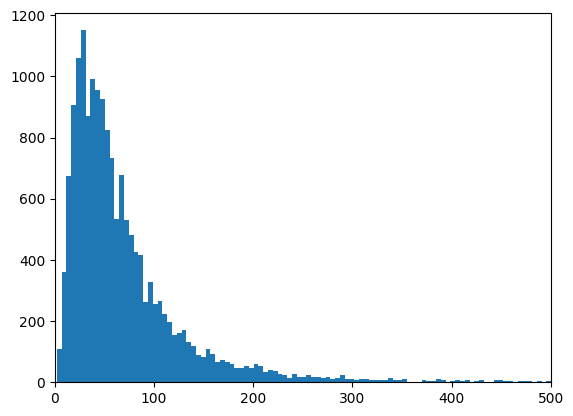

In [24]:
# vẽ biểu đồ thể hiện phân bố chiều dài của câu trong tập dữ liệu.
import matplotlib.pyplot as plt

plt.hist([len(s) for s in train_texts], bins=192)
plt.xlim(0, 500)
plt.show()

In [25]:
lens = [len(tokenizer(t, truncation=False)['input_ids']) for t in train_texts]
p95, p99 = int(np.percentile(lens, 95)), int(np.percentile(lens, 99))
print('token p95/p99:', p95, p99)
max_len = min(256, max(128, p95))

token p95/p99: 53 99


In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128, original_texts=None,
                 e2v=None, include_emoji_vectors=False, emoji_dim=300, emoji_k=8):
        self.texts = [str(text) for text in texts]
        self.original_texts = [str(text) for text in (original_texts if original_texts is not None else texts)]
        self.labels = torch.tensor(labels, dtype=torch.float)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.e2v = e2v
        self.include_emoji_vectors = include_emoji_vectors
        self.emoji_dim = emoji_dim
        self.emoji_k = emoji_k

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        original_text = self.original_texts[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_attention_mask=True,
            return_token_type_ids=False,
            return_tensors='pt'
        )
        emoji_seq = extract_emoji_sequence(original_text)
        ids = []
        if "emoji_to_id" in globals():
            ids = [emoji_to_id.get(emo, 0) for emo in emoji_seq if emoji_to_id.get(emo, 0) != 0]
        ids = ids[:self.emoji_k]
        mask = [1] * len(ids)
        ids = ids + [0] * (self.emoji_k - len(ids))
        mask = mask + [0] * (self.emoji_k - len(mask))

        item = {
            'text': text,
            'original_text': original_text,
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'targets': self.labels[idx],
            'emoji_ids': torch.tensor(ids, dtype=torch.long),
            'emoji_mask': torch.tensor(mask, dtype=torch.long),
            'emoji_tokens': emoji_seq[:30] + [''] * max(0, 30 - len(emoji_seq)),
        }
        return item


def sentiment_collate_fn(batch):
    return {
        'text': [item['text'] for item in batch],
        'original_text': [item['original_text'] for item in batch],
        'input_ids': torch.stack([item['input_ids'] for item in batch]),
        'attention_mask': torch.stack([item['attention_mask'] for item in batch]),
        'targets': torch.stack([item['targets'] for item in batch]),
        'emoji_ids': torch.stack([item['emoji_ids'] for item in batch]).long(),
        'emoji_mask': torch.stack([item['emoji_mask'] for item in batch]).long(),
        'emoji_tokens': [list(item['emoji_tokens']) for item in batch],
    }


# Datasets and DataLoaders are created inside run_experiment() for each config.


In [27]:
# Dataset previews are performed inside run_experiment() after config-specific creation.

In [28]:
# Global dataset previews removed; run_experiment() owns all datasets.

In [29]:
# Token mapping inspection is deferred to config-specific datasets in run_experiment().

In [30]:
# DataLoaders are created exclusively inside run_experiment() with sentiment_collate_fn.

## Model

In [31]:
# Load tokenizer và model
class ModelSentimentClassifier(nn.Module):
    def __init__(self, n_classes, model_type='pho'):
        super(ModelSentimentClassifier, self).__init__()
        # Select BERT model
        if model_type == 'pho':
            bert_model = 'vinai/phobert-base-v2'
        elif model_type == 'viso':
            bert_model = 'uitnlp/visobert'
        elif model_type == 'cafe':
            bert_model = 'uitnlp/CafeBERT'
        elif model_type == 'vi':
            bert_model = 'FPTAI/vibert-base-cased'

        # Load config with custom dropout settings
        config = AutoConfig.from_pretrained(
            bert_model,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1
        )

        # Download BERT
        self.bert = AutoModel.from_pretrained(bert_model, config=config)
        self.drop = nn.Dropout(p=0.2)
        self.fc = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask, *args, **kwargs):
        last_hidden_state, output = self.bert(
            input_ids = input_ids,
            attention_mask = attention_mask,
            return_dict = False # Dropout sẽ báo lỗi nếu không có điều này
        )

        x = self.drop(output)
        x = self.fc(x)
        return {'logits': x} # add more if needed

model = ModelSentimentClassifier(n_classes=len(label_dict), model_type=model_type).to(device)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = torch.nn.DataParallel(model)
model

# model_bert = "uitnlp/visobert"
# tokenizer = AutoTokenizer.from_pretrained(model_bert, use_fast=False) # https://huggingface.co/uitnlp/visobert
# model = AutoModelForSequenceClassification.from_pretrained(model_bert, num_labels=28) # AutoModelForSequenceClassification, model Bert thêm 2 layers Dense và Dropout với droprate = 0.1.
# model.to(device) # Move model to GPU if GPU is available


2026-06-21 04:25:01.835060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782015902.057140      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782015902.117765      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782015902.642514      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782015902.642548      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782015902.642551      24 computation_placer.cc:177] computation placer alr

pytorch_model.bin:   0%|          | 0.00/390M [00:00<?, ?B/s]

Some weights of XLMRobertaModel were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/390M [00:00<?, ?B/s]

Using 2 GPUs


DataParallel(
  (module): ModelSentimentClassifier(
    (bert): XLMRobertaModel(
      (embeddings): XLMRobertaEmbeddings(
        (word_embeddings): Embedding(15004, 768, padding_idx=1)
        (position_embeddings): Embedding(514, 768, padding_idx=1)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): XLMRobertaEncoder(
        (layer): ModuleList(
          (0-11): 12 x XLMRobertaLayer(
            (attention): XLMRobertaAttention(
              (self): XLMRobertaSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): XLMRobertaSelfOutput(
           

In [32]:
# Hàm để tính toán số lượng tham số và phân loại chúng
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params

    # In ra các lớp và tham số trainable/non-trainable
    print(f"\n--- Trainable vs Non-trainable Parameters ---")
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"Trainable: {name} ({param.numel()} parameters)")
        else:
            print(f"Non-trainable: {name} ({param.numel()} parameters)")

    return total_params, trainable_params, non_trainable_params

# Tính toán và hiển thị kết quả
total_params, trainable_params, non_trainable_params = count_parameters(model)
print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Non-trainable params: {non_trainable_params:,}")


--- Trainable vs Non-trainable Parameters ---
Trainable: module.bert.embeddings.word_embeddings.weight (11523072 parameters)
Trainable: module.bert.embeddings.position_embeddings.weight (394752 parameters)
Trainable: module.bert.embeddings.token_type_embeddings.weight (1536 parameters)
Trainable: module.bert.embeddings.LayerNorm.weight (768 parameters)
Trainable: module.bert.embeddings.LayerNorm.bias (768 parameters)
Trainable: module.bert.encoder.layer.0.attention.self.query.weight (589824 parameters)
Trainable: module.bert.encoder.layer.0.attention.self.query.bias (768 parameters)
Trainable: module.bert.encoder.layer.0.attention.self.key.weight (589824 parameters)
Trainable: module.bert.encoder.layer.0.attention.self.key.bias (768 parameters)
Trainable: module.bert.encoder.layer.0.attention.self.value.weight (589824 parameters)
Trainable: module.bert.encoder.layer.0.attention.self.value.bias (768 parameters)
Trainable: module.bert.encoder.layer.0.attention.output.dense.weight (58982

In [33]:
# Optimizer and scheduler are created inside run_experiment() from each experiment config.

## Train and Test

In [34]:
# Loss function: Asymmetric Loss for multi-label classification.
# ASL works directly on logits; pos_weight from BCE is no longer used.
import torch
import torch.nn as nn

class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=0, clip=0.05, eps=1e-8, reduction='mean', pos_class_weight=None):
        super().__init__()
        if reduction not in {'mean', 'sum', 'none'}:
            raise ValueError(f'Unsupported reduction: {reduction}')
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps
        self.reduction = reduction
        if pos_class_weight is None:
            self.register_buffer('pos_class_weight', None)
        else:
            self.register_buffer('pos_class_weight', pos_class_weight.detach().float())

    def forward(self, x, y, pos_class_weight=None):
        if x.shape != y.shape:
            raise ValueError(
                f'logits shape {tuple(x.shape)} != targets shape {tuple(y.shape)}. '
                f'Check that emoji_ids are being passed correctly to the model.'
            )
        y = y.type_as(x)
        p = torch.sigmoid(x)
        p_m = torch.clamp(p - self.clip, min=0.0)
        log_pos = torch.log(torch.clamp(p, min=self.eps))
        log_neg = torch.log(torch.clamp(1.0 - p_m, min=self.eps))
        pos_loss = -y * torch.pow(1.0 - p, self.gamma_pos) * log_pos
        class_weight = self.pos_class_weight if pos_class_weight is None else pos_class_weight
        if class_weight is not None:
            pos_loss = pos_loss * class_weight.to(x.device).view(1, -1)
        neg_loss = -(1.0 - y) * torch.pow(p_m, self.gamma_neg) * log_neg
        loss = pos_loss + neg_loss
        if self.reduction == 'mean':
            return loss.mean()
        if self.reduction == 'sum':
            return loss.sum()
        return loss

loss_fn = AsymmetricLoss(gamma_neg=4, gamma_pos=0, clip=0.05).to(device)
print(loss_fn)


AsymmetricLoss()


In [ ]:
class ClusteringContrastiveLoss(nn.Module):
    def __init__(self, tau=0.07, margin=0.3):
        super().__init__()
        self.tau = tau
        self.margin = margin
        self.label_to_cluster = {
            8: 0, 0: 0, 1: 0, 2: 0, 3: 0, 7: 0, 9: 0, 10: 0, 5: 0, 6: 0,
            11: 1, 4: 1,
            24: 2, 25: 2, 23: 2, 26: 2, 19: 2, 16: 2,
            20: 3, 21: 3, 18: 3, 22: 3,
            15: 4, 14: 4, 12: 4, 13: 4,
            27: 5
        }
        M = torch.zeros(28, 6)
        for label_idx, cluster_idx in self.label_to_cluster.items():
            M[label_idx, cluster_idx] = 1.0
        self.register_buffer('M', M)

    def forward(self, z, y):
        B = z.size(0)
        if B <= 1:
            return torch.tensor(0.0, device=z.device)
        S = torch.matmul(y, self.M)
        S_bin = (S > 0).float()
        shared = torch.matmul(S_bin, S_bin.T)
        shared_mask = (shared > 0).float()
        identity_mask = torch.eye(B, device=z.device)
        pos_mask = shared_mask * (1.0 - identity_mask)
        neg_mask = (1.0 - shared_mask) * (1.0 - identity_mask)
        similarity_matrix = torch.matmul(z, z.T)
        logits_sim = similarity_matrix / self.tau
        logits_sim = logits_sim.masked_fill(
            torch.eye(B, dtype=torch.bool, device=z.device), float('-inf')
        )
        log_sum_k = torch.logsumexp(logits_sim, dim=-1, keepdim=True)
        L_pos_matrix = log_sum_k - logits_sim
        pos_losses = L_pos_matrix[pos_mask.bool()]
        L_neg_matrix = torch.clamp(similarity_matrix - self.margin, min=0.0)
        neg_losses = L_neg_matrix[neg_mask.bool()]
        mean_pos = torch.mean(pos_losses) if pos_losses.numel() > 0 else torch.tensor(0.0, device=z.device)
        mean_neg = torch.mean(neg_losses) if neg_losses.numel() > 0 else torch.tensor(0.0, device=z.device)
        return mean_pos + mean_neg

class LabelDescriptionLoss(nn.Module):
    def __init__(self, backbone, tokenizer, device, tau=0.07):
        super().__init__()
        self.tau = tau
        self.tokenizer = tokenizer
        self.descriptions = [
            'amusement: cảm xúc vui vẻ, giải trí và gây cười nhẹ nhàng',
            'excitement: cảm giác hào hứng, phấn khích trước điều gì đó thú vị',
            'joy: niềm vui sướng, hạnh phúc tràn ngập năng lượng tích cực',
            'love: tình yêu thương và sự gắn bó sâu sắc dành cho người khác',
            'desire: khao khát hoặc thèm muốn có được một điều gì đó',
            'optimism: sự lạc quan và niềm tin vào tương lai tươi sáng',
            'caring: sự quan tâm, chăm sóc và lo lắng cho người khác',
            'pride: lòng tự hào và sự tự tôn về bản thân hoặc thành tựu',
            'admiration: sự ngưỡng mộ, kính trọng và đánh giá cao người khác',
            'gratitude: sự biết ơn sâu sắc trước sự giúp đỡ hay lòng tốt',
            'relief: cảm giác nhẹ nhõm khi trút bỏ được lo lắng căng thẳng',
            'approval: sự tán thành, đồng ý và ủng hộ ý kiến hành động',
            'realization: sự nhận ra, thấu hiểu hoặc phát hiện mới mẻ',
            'surprise: sự ngạc nhiên, bất ngờ trước việc không ngờ tới',
            'curiosity: sự tò mò, ham học hỏi và tìm hiểu mọi thứ',
            'confusion: sự bối rối, hoang mang chưa hiểu rõ vấn đề',
            'fear: nỗi sợ hãi, lo lắng trước mối nguy hiểm đe dọa',
            'nervousness: sự lo lắng, bồn chồn trước một sự kiện sắp diễn ra',
            'remorse: sự hối hận, ăn năn tự trách về lỗi lầm đã qua',
            'embarrassment: sự ngượng ngùng, xấu hổ trước mặt người khác',
            'disappointment: sự thất vọng khi kết quả không như ý muốn',
            'sadness: nỗi buồn bã, u sầu và chán nản trong lòng',
            'grief: sự đau buồn sâu sắc trước mất mát lớn lao',
            'disgust: sự ghê tởm, khó chịu trước điều bẩn thỉu xấu xa',
            'anger: sự tức giận, giận dữ phẫn nộ mạnh mẽ',
            'annoyance: sự khó chịu, bực mình vì phiền toái nhỏ nhặt',
            'disapproval: sự phản đối, không chấp nhận một hành vi nào đó',
            'neutral: trạng thái trung tính bình thường không có cảm xúc đặc biệt'
        ]
        hidden_size = getattr(backbone.config, 'hidden_size', None) or getattr(backbone.config, 'dim', None)
        self.register_buffer('d_k', torch.empty(len(self.descriptions), hidden_size, device=device))
        self.refresh(backbone, device)

    def refresh(self, backbone, device):
        was_training = backbone.training
        backbone.eval()
        with torch.no_grad():
            inputs = self.tokenizer(
                self.descriptions, padding=True, truncation=True, return_tensors='pt'
            ).to(device)
            outputs = backbone(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'])
            H = outputs.last_hidden_state
            m = inputs['attention_mask'].unsqueeze(-1).float()
            d_k = (H * m).sum(1) / m.sum(1).clamp(min=1e-9)
            d_k = torch.nn.functional.normalize(d_k, p=2, dim=-1)
            self.d_k.copy_(d_k)
        if was_training:
            backbone.train()

    def forward(self, z, y):
        logits = torch.matmul(z, self.d_k.T) / self.tau
        return F.binary_cross_entropy_with_logits(logits, y.float())

def _base_model(model):
    return model.module if isinstance(model, torch.nn.DataParallel) else model


def _prepare_emoji_vectors(model, emoji_tokens, device):
    m = _base_model(model)
    if hasattr(m, "emoji_attn"):
        return None
    use_emoji_branch = bool(getattr(m, 'use_emoji_branch', hasattr(m, 'emoji_encoder')))
    if not use_emoji_branch or emoji_tokens is None:
        return None
    emoji_encoder = getattr(m, 'emoji_encoder', None)
    if emoji_encoder is None:
        return None
    return emoji_encoder(emoji_tokens, device=device)


def get_logits(model, data, device='cpu', emoji_vectors=None, return_outputs=False):
    input_ids = data['input_ids'].to(device)
    attention_mask = data['attention_mask'].to(device)
    emoji_ids = data.get('emoji_ids', None)
    emoji_mask = data.get('emoji_mask', None)
    emoji_tokens = data.get('emoji_tokens', None)
    m = _base_model(model)

    if emoji_vectors is None:
        emoji_vectors = _prepare_emoji_vectors(model, emoji_tokens, device)

    import inspect
    sig = inspect.signature(m.forward)
    forward_kwargs = {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
    }
    if emoji_vectors is not None and 'emoji_vectors' in sig.parameters:
        forward_kwargs['emoji_vectors'] = emoji_vectors
    if emoji_ids is not None and 'emoji_ids' in sig.parameters:
        forward_kwargs['emoji_ids'] = emoji_ids.to(device)
    if emoji_mask is not None and 'emoji_mask' in sig.parameters:
        forward_kwargs['emoji_mask'] = emoji_mask.to(device)
    outputs = model(**forward_kwargs)

    logits = None
    cls_embedding = None
    if isinstance(outputs, dict):
        logits = outputs.get('logits')
        cls_embedding = outputs.get('cls_embedding')
    elif hasattr(outputs, 'logits'):
        logits = outputs.logits
        cls_embedding = getattr(outputs, 'cls_embedding', getattr(outputs, 'pooled', None))
    elif isinstance(outputs, (tuple, list)):
        if len(outputs) > 0:
            logits = outputs[0]
        if len(outputs) > 1:
            cls_embedding = outputs[1]
    elif isinstance(outputs, torch.Tensor):
        logits = outputs
    if return_outputs:
        return logits, cls_embedding, outputs
    return logits, cls_embedding

def _binary_sym_kl(logits_a, logits_b, eps=1e-6):
    pa = torch.sigmoid(logits_a).clamp(eps, 1 - eps)
    pb = torch.sigmoid(logits_b).clamp(eps, 1 - eps)
    kl_ab = pa * (torch.log(pa) - torch.log(pb)) + (1 - pa) * (torch.log(1 - pa) - torch.log(1 - pb))
    kl_ba = pb * (torch.log(pb) - torch.log(pa)) + (1 - pb) * (torch.log(1 - pb) - torch.log(1 - pa))
    return 0.5 * (kl_ab + kl_ba).mean()


def _neutral_hierarchy_loss(outputs, targets):
    if not isinstance(outputs, dict) or outputs.get("emotional_logit") is None:
        return torch.tensor(0.0, device=targets.device)
    y_any = (targets[:, :27].sum(1) > 0).float().unsqueeze(1)
    return F.binary_cross_entropy_with_logits(outputs["emotional_logit"], y_any)


def train(model, data_loader, loss_fn, optimizer, device='cpu', threshold=0.5,
          use_rdrop=False, alpha_rdrop=5.0, use_taco=False, ccl_fn=None, ldl_fn=None,
          lambda_ccl=0.1, lambda_ldl=0.1, lr_scheduler=None, epoch=0,
          use_neu_hierarchy=False, grad_accum_steps=1, use_amp=False):
    model.train()
    losses = []
    all_targets = []
    all_preds = []
    optimizer.zero_grad()
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp and torch.cuda.is_available())
    for step, data in enumerate(data_loader):
        targets = data['targets'].to(device)
        emoji_vectors = _prepare_emoji_vectors(model, data.get('emoji_tokens', None), device)
        with torch.cuda.amp.autocast(enabled=use_amp and torch.cuda.is_available()):
            if use_rdrop:
                logits1, cls1, outputs1 = get_logits(model, data, device=device, emoji_vectors=emoji_vectors, return_outputs=True)
                logits2, cls2, outputs2 = get_logits(model, data, device=device, emoji_vectors=emoji_vectors, return_outputs=True)
                L_main = 0.5 * (loss_fn(logits1, targets) + loss_fn(logits2, targets))
                loss = L_main + alpha_rdrop * _binary_sym_kl(logits1, logits2)
                if use_neu_hierarchy:
                    loss = loss + 0.05 * (_neutral_hierarchy_loss(outputs1, targets) + _neutral_hierarchy_loss(outputs2, targets))
                logits_for_pred = logits1
                cls_for_taco = cls1
            else:
                logits_for_pred, cls_for_taco, outputs = get_logits(model, data, device=device, emoji_vectors=emoji_vectors, return_outputs=True)
                loss = loss_fn(logits_for_pred, targets)
                if use_neu_hierarchy:
                    loss = loss + 0.1 * _neutral_hierarchy_loss(outputs, targets)
            if use_taco and epoch > 0 and cls_for_taco is not None:
                z = torch.nn.functional.normalize(cls_for_taco, p=2, dim=-1)
                loss_ccl = ccl_fn(z, targets) if ccl_fn is not None else 0.0
                loss_ldl = ldl_fn(z, targets) if ldl_fn is not None else 0.0
                loss = loss + lambda_ccl * loss_ccl + lambda_ldl * loss_ldl
            loss = loss / grad_accum_steps
        losses.append(float(loss.detach().item() * grad_accum_steps))
        scaler.scale(loss).backward()
        if (step + 1) % grad_accum_steps == 0 or (step + 1) == len(data_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            if lr_scheduler is not None:
                lr_scheduler.step()
        preds = (torch.sigmoid(logits_for_pred) >= threshold).int()
        all_targets.append(targets.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)
    mean_loss = np.mean(losses)
    correct_per_label = (all_targets == all_preds).sum(axis=0)
    average_accuracy = (correct_per_label / all_targets.shape[0]).mean()
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    print(f'Train Loss: {mean_loss:.4f} | Average Accuracy: {average_accuracy:.4f} | Macro F1: {macro_f1:.4f}')
    return mean_loss, average_accuracy, macro_f1

def eval_model(model, data_loader, loss_fn, device='cpu', threshold=0.5):
    model.eval()
    losses = []
    all_targets = []
    all_preds = []
    with torch.no_grad():
        for data in data_loader:
            targets = data['targets'].to(device)
            logits, _ = get_logits(model, data, device=device)
            loss = loss_fn(logits, targets)
            losses.append(loss.item())
            preds = (torch.sigmoid(logits) >= threshold).int()
            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)
    mean_loss = np.mean(losses)
    correct_per_label = (all_targets == all_preds).sum(axis=0)
    average_accuracy = (correct_per_label / all_targets.shape[0]).mean()
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    print(f'Validation Loss: {mean_loss:.4f} | Average Accuracy: {average_accuracy:.4f} | Macro F1: {macro_f1:.4f}')
    return mean_loss, average_accuracy, macro_f1

def test_model(model, data_loader, device='cpu', threshold=0.5):
    model.to(device)
    model.eval()
    texts, original_texts, predict_probs, predicts, real_values = [], [], [], [], []
    with torch.no_grad():
        for data in data_loader:
            targets = data['targets'].to(device)
            logits, _ = get_logits(model, data, device=device)
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).int()
            texts.extend(data['text'])
            original_texts.extend(data.get('original_text', data['text']))
            predicts.extend(preds.cpu().numpy())
            predict_probs.extend(probs.cpu().numpy())
            real_values.extend(targets.cpu().numpy())
    predicts = torch.tensor(np.asarray(predicts))
    predict_probs = torch.tensor(np.asarray(predict_probs))
    real_values = torch.tensor(np.asarray(real_values))
    return predict_probs, predicts, real_values


In [36]:
def eval_model(model, data_loader, loss_fn, device='cpu', threshold=0.5):
    model.eval()
    losses = []
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for data in data_loader:
            targets = data['targets'].to(device)
            logits, _ = get_logits(model, data, device=device)

            loss = loss_fn(logits, targets)
            losses.append(loss.item())

            preds = torch.sigmoid(logits)
            preds = (preds >= threshold).int()

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)

    mean_loss = np.mean(losses)
    correct_per_label = (all_targets == all_preds).sum(axis=0)
    total_per_label = all_targets.shape[0]
    label_accuracies = correct_per_label / total_per_label
    average_accuracy = label_accuracies.mean()
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

    print(f'Validation Loss: {mean_loss:.4f} | Average Accuracy: {average_accuracy:.4f} | Macro F1: {macro_f1:.4f}')
    return mean_loss, average_accuracy, macro_f1


eval = eval_model


In [37]:
def test_model(model, data_loader, device='cpu', threshold=0.5):
    model.to(device)
    model.eval()
    texts, original_texts, predict_probs, predicts, real_values = [], [], [], [], []

    with torch.no_grad():
        for data in data_loader:
            targets = data['targets'].to(device)
            logits, _ = get_logits(model, data, device=device)

            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).int()

            texts.extend(data['text'])
            original_texts.extend(data.get('original_text', data['text']))
            predicts.extend(preds.cpu().numpy())
            predict_probs.extend(probs.cpu().numpy())
            real_values.extend(targets.cpu().numpy())

    predicts = torch.tensor(np.asarray(predicts))
    predict_probs = torch.tensor(np.asarray(predict_probs))
    real_values = torch.tensor(np.asarray(real_values))

    return predict_probs, predicts, real_values


test = test_model


In [38]:
import os

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("checkpoints folder ready")
!ls /kaggle/working

checkpoints folder ready
checkpoints  __notebook__.ipynb  reports


In [ ]:
RUN_B1   = False   # B1_emoji_xattn
RUN_B2   = False   # B2_VN_emoji
RUN_B3   = False   # B3_label_graph
RUN_B4   = False   # B4_neu_hierarchy
RUN_C42  = False   # C_star_seed42
RUN_C1   = False   # C_star_seed1
RUN_C7   = False   # C_star_seed7


In [ ]:
# Unified Experiment Runner for B/C ablations.
import time
import json
import csv
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

ARTIFACT_ROOT = os.path.join(WORKING_DIR, "artifacts")
EXPERIMENT_BUNDLE_DIR = os.path.join(WORKING_DIR, 'experiment_bundles')
os.makedirs(ARTIFACT_ROOT, exist_ok=True)
os.makedirs(EXPERIMENT_BUNDLE_DIR, exist_ok=True)

def find_optimal_thresholds_per_class(probs, targets, grid=None, min_support=10,
                                      lo=0.15, hi=0.85, default=0.5):
    if grid is None:
        grid = np.arange(0.05, 0.95, 0.01)
    n_classes = probs.shape[1]
    best_t = np.full(n_classes, default, dtype=float)
    for c in range(n_classes):
        if targets[:, c].sum() < min_support:
            best_t[c] = default
            continue
        best_f1 = -1.0
        for t in grid:
            f1 = f1_score(targets[:, c], (probs[:, c] >= t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_t[c] = f1, t
        best_t[c] = float(np.clip(best_t[c], lo, hi))
    return best_t

def save_classification_outputs(real_values, predicts, report_path, title):
    labels = list(label_dict.values())
    report_text = classification_report(
        real_values, predicts, target_names=labels, zero_division=0
    )
    report_dict = classification_report(
        real_values, predicts, target_names=labels, zero_division=0, output_dict=True
    )
    parent_dir = os.path.dirname(report_path)
    if parent_dir:
        os.makedirs(parent_dir, exist_ok=True)
    if report_path.endswith(".txt"):
        with open(report_path, "w", encoding="utf-8") as f:
            f.write(report_text)
        report_df = pd.DataFrame(report_dict).transpose()
    else:
        report_df = pd.DataFrame(report_dict).transpose()
        report_df.index.name = 'class'
        report_df.to_csv(report_path)
    test_macro_f1 = f1_score(real_values, predicts, average='macro', zero_division=0)
    print(title)
    print(report_text)
    print('Test Macro F1:', test_macro_f1)
    return report_df, test_macro_f1

def _json_safe(value):
    if isinstance(value, dict):
        return {str(k): _json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if torch.is_tensor(value):
        return {"tensor_shape": list(value.shape), "dtype": str(value.dtype)}
    return value

def _base_model_state_dict(model):
    return _base_model(model).state_dict()

def _clean_state_dict(state_dict):
    return {k.replace("module.", "", 1): v for k, v in state_dict.items()}

def safe_torch_load(path, device):
    try:
        return torch.load(path, weights_only=True, map_location=device)
    except Exception as weights_only_error:
        print(f'weights_only=True could not load {path}; retrying legacy module checkpoint.')
        try:
            return torch.load(path, weights_only=False, map_location=device)
        except Exception:
            raise weights_only_error

def load_checkpoint_as_model(path, model_cls, model_kwargs, device):
    checkpoint = safe_torch_load(path, device)
    if isinstance(checkpoint, nn.Module):
        checkpoint.to(device)
        return checkpoint
    if isinstance(checkpoint, dict):
        state_dict = None
        for key in ('state_dict', 'model_state_dict', 'model'):
            if key in checkpoint:
                state_dict = checkpoint[key]
                break
        if state_dict is None:
            state_dict = checkpoint
        model = model_cls(**model_kwargs).to(device)
        model.load_state_dict(_clean_state_dict(state_dict), strict=True)
        return model
    raise TypeError(f'Unexpected checkpoint type: {type(checkpoint)}')

def _resolve_emoji_init(cfg):
    emoji_init = cfg.get("emoji_init", None)
    if emoji_init is not None:
        return emoji_init.float()
    key = cfg.get("emoji_init_key", "vn")
    if key == "e2v" and "emoji_e2v_init_matrix" in globals():
        return emoji_e2v_init_matrix.float()
    if "emoji_init_matrix" in globals():
        return emoji_init_matrix.float()
    raise ValueError("emoji_init_matrix is not available. Run STEP 2 before B/C configs.")

def _resolve_A_cooc(cfg):
    A = cfg.get("A_cooc", None)
    if A is not None:
        return A.float()
    if "A_cooc" in globals():
        return A_cooc.float()
    raise ValueError("A_cooc is not available. Run STEP 1 before graph configs.")

def _model_spec_from_cfg(cfg):
    model_cls_name = cfg.get("model_cls", "graph")
    dropout = cfg.get("dropout", 0.2)
    if model_cls_name == "base":
        e2v_loc = None
        if cfg.get("use_emoji_branch", True):
            e2v_loc = load_emoji2vec(_emoji2vec_path() if "_emoji2vec_path" in globals() else os.path.join(DATA_ROOT, "emoji2vec.bin"))
        return EmojiAwareViSoBERT, {
            "model_name": "uitnlp/visobert",
            "num_labels": len(label_dict),
            "emoji_dim": 300,
            "dropout": dropout,
            "e2v": e2v_loc,
        }
    if model_cls_name == "graph":
        return EmojiLabelGraphViSoBERT, {
            "model_name": "uitnlp/visobert",
            "emoji_init_matrix": _resolve_emoji_init(cfg),
            "A_cooc": _resolve_A_cooc(cfg),
            "n_labels": len(label_dict),
            "use_emoji_attn": cfg.get("use_emoji_attn", True),
            "use_label_graph": cfg.get("use_label_graph", True),
            "dropout": dropout,
        }
    raise ValueError(f"Unknown model_cls={model_cls_name}")

def _save_run_checkpoint(path, model, epoch, val_mf1, cfg):
    torch.save({
        "state_dict": _base_model_state_dict(model),
        "epoch": int(epoch),
        "val_mf1": float(val_mf1),
        "cfg": _json_safe(cfg),
    }, path)

def _write_thresholds(path, thresholds):
    labels = list(label_dict.values())
    thresholds_dict = {labels[i]: float(thresholds[i]) for i in range(len(labels))}
    with open(path, "w", encoding="utf-8") as f:
        json.dump(thresholds_dict, f, indent=2, ensure_ascii=False)
    return thresholds_dict

def run_experiment(cfg):
    print("=" * 60)
    print(f"RUNNING EXPERIMENT: {cfg['name']}")
    print("=" * 60)
    seed = cfg.get("seed", 42)
    set_seed(seed)
    optimize_threshold = True

    use_asl = cfg.get("use_asl", True)
    use_taco = cfg.get("use_taco", False)
    use_rdrop = cfg.get("use_rdrop", False)
    use_cb = cfg.get("use_cb", True)
    use_neu_hierarchy = cfg.get("use_neu_hierarchy", False)
    alpha_rdrop = cfg.get("alpha_rdrop", 5.0)
    epochs = cfg.get("epochs", 10)
    lr = cfg.get("lr", 2e-5)
    weight_decay = cfg.get("weight_decay", 0.01)
    gamma_neg = cfg.get("gamma_neg", 4)
    gamma_pos = cfg.get("gamma_pos", 0)
    clip = cfg.get("clip", 0.05)
    early_stopping_patience = cfg.get("early_stopping_patience", 3)
    batch_size = cfg.get("batch_size", 32)
    grad_accum_steps = cfg.get("grad_accum_steps", 1)
    use_amp = cfg.get("use_amp", False)
    differential_lr = cfg.get("differential_lr", False)
    taco_tau = cfg.get("taco_tau", 0.07)
    taco_margin = cfg.get("taco_margin", 0.3)
    lambda_ccl = cfg.get("lambda_ccl", 0.1)
    lambda_ldl = cfg.get("lambda_ldl", 0.1)

    train_ds = SentimentDataset(train_texts, train_labels, tokenizer, max_len=max_len, original_texts=train_original_texts)
    val_ds = SentimentDataset(val_texts, val_labels, tokenizer, max_len=max_len, original_texts=val_original_texts)
    test_ds = SentimentDataset(test_texts, test_labels, tokenizer, max_len=max_len, original_texts=test_original_texts)
    train_ldr = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, collate_fn=sentiment_collate_fn)
    val_ldr = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=sentiment_collate_fn)
    test_ldr = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=sentiment_collate_fn)

    model_cls, model_kwargs = _model_spec_from_cfg(cfg)
    model = model_cls(**model_kwargs).to(device)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for training")
        model = torch.nn.DataParallel(model)

    artifacts_dir = os.path.join(ARTIFACT_ROOT, cfg["name"])
    os.makedirs(artifacts_dir, exist_ok=True)
    best_ckpt_path = os.path.join(artifacts_dir, "best_ckpt.pt")
    last_ckpt_path = os.path.join(artifacts_dir, "last_ckpt.pt")
    val_log_path = os.path.join(artifacts_dir, "val_log.csv")
    threshold_path = os.path.join(artifacts_dir, "thresholds.json")

    start_epoch = 0
    best_val_f1 = -1.0
    best_epoch = 0
    best_thresholds = np.full(len(label_dict), 0.5, dtype=float)
    if cfg.get("resume", False) and os.path.exists(last_ckpt_path):
        ckpt = safe_torch_load(last_ckpt_path, device)
        _base_model(model).load_state_dict(_clean_state_dict(ckpt["state_dict"]), strict=True)
        start_epoch = int(ckpt.get("epoch", 0))
        best_val_f1 = float(ckpt.get("val_mf1", -1.0))
        print(f"Resuming from epoch {start_epoch}, val_mf1={best_val_f1:.4f}")
        if os.path.exists(threshold_path):
            with open(threshold_path, "r", encoding="utf-8") as f:
                threshold_dict = json.load(f)
            labels = list(label_dict.values())
            best_thresholds = np.array([threshold_dict[label] for label in labels], dtype=float)

    cb_w = None
    if use_cb:
        counts = np.sum(train_labels, axis=0)
        beta = 0.999
        cb_w_np = (1 - beta) / (1 - np.power(beta, np.maximum(counts, 1)))
        cb_w_np = cb_w_np / cb_w_np.mean()
        cb_w = torch.tensor(cb_w_np, dtype=torch.float32, device=device)
    if use_asl:
        loss_fn = AsymmetricLoss(gamma_neg=gamma_neg, gamma_pos=gamma_pos, clip=clip, pos_class_weight=cb_w).to(device)
    else:
        label_counts = np.sum(train_labels, axis=0)
        total_samples = len(train_labels)
        pos_weight = torch.tensor([(total_samples - count) / max(count, 1e-8) for count in label_counts], device=device)
        loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    ccl_fn = ClusteringContrastiveLoss(tau=taco_tau, margin=taco_margin).to(device) if use_taco else None
    ldl_fn = None
    if use_taco:
        base = _base_model(model)
        ldl_fn = LabelDescriptionLoss(base.backbone, tokenizer, device, tau=taco_tau).to(device)

    if differential_lr:
        m = _base_model(model)
        backbone_params = list(m.backbone.parameters())
        backbone_ids = {id(p) for p in backbone_params}
        head_params = [p for p in m.parameters() if id(p) not in backbone_ids]
        optimizer = AdamW([
            {"params": backbone_params, "lr": lr},
            {"params": head_params, "lr": cfg.get("head_lr", 5e-5)},
        ], weight_decay=weight_decay)
    else:
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = max(1, math.ceil(len(train_ldr) / grad_accum_steps) * max(epochs - start_epoch, 1))
    lr_scheduler = get_scheduler(
        "linear", optimizer=optimizer,
        num_warmup_steps=max(1, math.ceil(len(train_ldr) / grad_accum_steps)),
        num_training_steps=total_steps,
    )

    weak_classes = ['disapproval', 'neutral', 'disappointment', 'nervousness', 'confusion', 'realization']
    weak_indices = {name: int(idx) for idx, name in label_dict.items() if name in weak_classes}
    val_f1_history = []
    val_f1_p50_history = []
    patience_counter = 0
    start_time = time.time()

    if start_epoch == 0 or not os.path.exists(val_log_path):
        with open(val_log_path, "w", newline="", encoding="utf-8") as f:
            csv.writer(f).writerow(["epoch", "train_loss", "val_mf1"])

    for epoch in range(start_epoch, epochs):
        if use_taco and epoch > 0 and ldl_fn is not None:
            ldl_fn.refresh(_base_model(model).backbone, device)
        train_loss, train_acc, train_f1 = train(
            model, train_ldr, loss_fn, optimizer, device, threshold=0.5,
            use_rdrop=use_rdrop, alpha_rdrop=alpha_rdrop,
            use_taco=use_taco, ccl_fn=ccl_fn, ldl_fn=ldl_fn,
            lambda_ccl=lambda_ccl, lambda_ldl=lambda_ldl,
            lr_scheduler=lr_scheduler, epoch=epoch,
            use_neu_hierarchy=use_neu_hierarchy,
            grad_accum_steps=grad_accum_steps, use_amp=use_amp,
        )
        val_loss, val_acc, val_f1_p50 = eval_model(model, val_ldr, loss_fn, device, threshold=0.5)
        val_probs, _, val_targets = test_model(model, val_ldr, device, threshold=0.5)
        val_probs_np = val_probs.numpy()
        val_targets_np = val_targets.numpy().astype(int)
        epoch_thresholds = find_optimal_thresholds_per_class(val_probs_np, val_targets_np)
        val_preds_tuned = (val_probs_np >= epoch_thresholds.reshape(1, -1)).astype(int)
        val_macro_tuned = f1_score(val_targets_np, val_preds_tuned, average='macro', zero_division=0)
        val_f1_history.append(val_macro_tuned)
        val_f1_p50_history.append(val_f1_p50)
        with open(val_log_path, "a", newline="", encoding="utf-8") as f:
            csv.writer(f).writerow([epoch + 1, float(train_loss), float(val_macro_tuned)])
        print(f'Epoch {epoch+1} Val Macro F1 @0.5: {val_f1_p50:.4f} | tuned: {val_macro_tuned:.4f}')
        per_class_f1 = f1_score(val_targets_np, val_preds_tuned, average=None, zero_division=0)
        print(f"Epoch {epoch+1} - Weak classes Val F1:")
        for name, idx in weak_indices.items():
            print(f"  {name}: {per_class_f1[idx]:.4f}")

        _save_run_checkpoint(last_ckpt_path, model, epoch + 1, val_macro_tuned, cfg)
        if val_macro_tuned > best_val_f1:
            best_val_f1 = val_macro_tuned
            best_epoch = epoch + 1
            patience_counter = 0
            best_thresholds = epoch_thresholds.copy()
            print(f"Tuned val F1 improved to {val_macro_tuned:.4f}. Saving {best_ckpt_path}")
            _save_run_checkpoint(best_ckpt_path, model, epoch + 1, val_macro_tuned, cfg)
            _write_thresholds(threshold_path, best_thresholds)
        else:
            patience_counter += 1
            print(f"Tuned val F1 did not improve. Patience: {patience_counter}/{early_stopping_patience}")
            if patience_counter >= early_stopping_patience:
                print("Early stopping triggered.")
                break

    training_time = time.time() - start_time
    print(f"Training finished in {training_time:.2f} seconds.")
    if not os.path.exists(best_ckpt_path):
        best_ckpt_path = last_ckpt_path
    print(f"Loading best checkpoint for final evaluation: {best_ckpt_path}")
    best_model = load_checkpoint_as_model(best_ckpt_path, model_cls, model_kwargs, device)

    val_probs, _, val_targets = test_model(best_model, val_ldr, device, threshold=0.5)
    val_probs_np = val_probs.numpy()
    val_targets_np = val_targets.numpy().astype(int)
    optimal_thresholds = best_thresholds.copy()
    test_probs, _, test_targets = test_model(best_model, test_ldr, device, threshold=0.5)
    test_probs_np = test_probs.numpy()
    test_targets_np = test_targets.numpy().astype(int)
    test_preds_p50 = (test_probs_np >= 0.5).astype(int)
    test_preds = (test_probs_np >= optimal_thresholds.reshape(1, -1)).astype(int)
    test_macro_f1_p50 = f1_score(test_targets_np, test_preds_p50, average='macro', zero_division=0)
    test_macro_f1_tuned = f1_score(test_targets_np, test_preds, average='macro', zero_division=0)
    print(f"{cfg['name']} Test Macro F1 @0.5: {test_macro_f1_p50:.4f}")
    print(f"{cfg['name']} Test Macro F1 @tuned: {test_macro_f1_tuned:.4f}")
    thresholds_dict = _write_thresholds(threshold_path, optimal_thresholds)

    np.save(os.path.join(artifacts_dir, "val_probs.npy"), val_probs_np)
    np.save(os.path.join(artifacts_dir, "val_targets.npy"), val_targets_np)
    np.save(os.path.join(artifacts_dir, "test_probs.npy"), test_probs_np)
    np.save(os.path.join(artifacts_dir, "test_targets.npy"), test_targets_np)
    report_path = os.path.join(artifacts_dir, "classification_report.txt")
    report_df, test_macro_f1 = save_classification_outputs(
        test_targets_np, test_preds, report_path, f"Classification Report - {cfg['name']}"
    )

    test_precision = precision_score(test_targets_np, test_preds, average='macro', zero_division=0)
    test_recall = recall_score(test_targets_np, test_preds, average='macro', zero_division=0)
    test_weighted_f1 = f1_score(test_targets_np, test_preds, average='weighted', zero_division=0)
    test_per_class_f1 = f1_score(test_targets_np, test_preds, average=None, zero_division=0)
    weak_class_f1s = {name: float(test_per_class_f1[idx]) for name, idx in weak_indices.items()}
    weak_class_mean_f1 = float(np.mean(list(weak_class_f1s.values())))

    return {
        "name": cfg["name"],
        "val_f1_history": val_f1_history,
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "test_macro_f1_p50": test_macro_f1_p50,
        "test_macro_f1": test_macro_f1,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_weighted_f1": test_weighted_f1,
        "weak_class_f1s": weak_class_f1s,
        "weak_class_mean_f1": weak_class_mean_f1,
        "training_time": training_time,
        "seed": seed,
        "checkpoint_path": best_ckpt_path,
        "threshold_path": threshold_path,
        "optimal_thresholds": optimal_thresholds,
        "val_probs": val_probs_np,
        "val_targets": val_targets_np,
        "test_probs": test_probs_np,
        "test_targets": test_targets_np,
        "config": _json_safe(dict(cfg)),
    }

def run_or_resume_experiment(cfg):
    return run_experiment(cfg)

BASE_BC_CFG = {
    "model_cls": "graph",
    "use_asl": True,
    "use_cb": True,
    "use_rdrop": False,
    "epochs": 10,
    "lr": 2e-5,
    "dropout": 0.2,
    "weight_decay": 0.01,
    "early_stopping_patience": 3,
    "optimize_threshold": True,
    "batch_size": 32,
    "grad_accum_steps": 1,
    "use_amp": False,
}

EXPERIMENTS = [
    dict(BASE_BC_CFG, name="B1_emoji_xattn", use_emoji_attn=True, use_label_graph=False,
         use_neu_hierarchy=False, emoji_init_key="e2v", emoji_init=globals().get("emoji_e2v_init_matrix")),
    dict(BASE_BC_CFG, name="B2_VN_emoji", use_emoji_attn=True, use_label_graph=False,
         use_neu_hierarchy=False, emoji_init_key="vn", emoji_init=globals().get("emoji_init_matrix")),
    dict(BASE_BC_CFG, name="B3_label_graph", use_emoji_attn=True, use_label_graph=True,
         use_neu_hierarchy=False, emoji_init_key="vn", emoji_init=globals().get("emoji_init_matrix"),
         A_cooc=globals().get("A_cooc")),
    dict(BASE_BC_CFG, name="B4_neu_hierarchy", use_emoji_attn=True, use_label_graph=True,
         use_neu_hierarchy=True, emoji_init_key="vn", emoji_init=globals().get("emoji_init_matrix"),
         A_cooc=globals().get("A_cooc")),
    dict(BASE_BC_CFG, name="C_star_seed42", seed=42, use_emoji_attn=True, use_label_graph=True,
         use_neu_hierarchy=False, emoji_init_key="vn", emoji_init=globals().get("emoji_init_matrix"),
         A_cooc=globals().get("A_cooc")),
    dict(BASE_BC_CFG, name="C_star_seed1", seed=1, resume=False, use_emoji_attn=True, use_label_graph=True,
         use_neu_hierarchy=False, emoji_init_key="vn", emoji_init=globals().get("emoji_init_matrix"),
         A_cooc=globals().get("A_cooc")),
    dict(BASE_BC_CFG, name="C_star_seed7", seed=7, resume=False, use_emoji_attn=True, use_label_graph=True,
         use_neu_hierarchy=False, emoji_init_key="vn", emoji_init=globals().get("emoji_init_matrix"),
         A_cooc=globals().get("A_cooc")),
]
experiment_config_by_name = {cfg["name"]: cfg for cfg in EXPERIMENTS}

def configure_c_star_from_best(best_name):
    if best_name not in ("B3_label_graph", "B4_neu_hierarchy"):
        raise ValueError("best_name must be 'B3_label_graph' or 'B4_neu_hierarchy'")
    source = dict(experiment_config_by_name[best_name])
    for seed, name in [(42, "C_star_seed42"), (1, "C_star_seed1"), (7, "C_star_seed7")]:
        cfg = dict(source)
        cfg.update({"name": name, "seed": seed, "resume": False, "optimize_threshold": True})
        experiment_config_by_name[name].update(cfg)
    print(f"C_star configs now mirror {best_name}")

_toggle_map = {
    "B1_emoji_xattn":   RUN_B1,
    "B2_VN_emoji":      RUN_B2,
    "B3_label_graph":   RUN_B3,
    "B4_neu_hierarchy": RUN_B4,
    "C_star_seed42":    RUN_C42,
    "C_star_seed1":     RUN_C1,
    "C_star_seed7":     RUN_C7,
}
experiment_results = []
for cfg in EXPERIMENTS:
    if _toggle_map.get(cfg["name"], False):
        experiment_results.append(run_or_resume_experiment(cfg))


In [ ]:
# C-star ensemble and statistical tests.
import os
import json
import math
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, classification_report

def _artifact_dir(name):
    candidates = [
        os.path.join(ARTIFACT_ROOT, name),
        os.path.join(WORKING_DIR, "artifacts", name),
        os.path.join("artifacts", name),
    ]
    for candidate in candidates:
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError(f"Artifact not found for {name}")

def _load_threshold_array(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    labels = list(label_dict.values())
    if isinstance(data, dict):
        return np.array([float(data[label]) for label in labels], dtype=float)
    return np.asarray(data, dtype=float)

def load_artifact(name):
    root = _artifact_dir(name)
    probs = np.load(os.path.join(root, "test_probs.npy"))
    targets = np.load(os.path.join(root, "test_targets.npy")).astype(int)
    thresholds = _load_threshold_array(os.path.join(root, "thresholds.json"))
    val_probs_path = os.path.join(root, "val_probs.npy")
    val_targets_path = os.path.join(root, "val_targets.npy")
    val_probs = np.load(val_probs_path) if os.path.exists(val_probs_path) else None
    val_targets = np.load(val_targets_path).astype(int) if os.path.exists(val_targets_path) else None
    return probs, targets, thresholds, val_probs, val_targets

def build_c_star_ensemble(seed_names=("C_star_seed42", "C_star_seed1", "C_star_seed7"), out_name="C_star_ensemble"):
    loaded = [load_artifact(name) for name in seed_names]
    test_probs = np.mean([x[0] for x in loaded], axis=0)
    test_targets = loaded[0][1]
    if all(x[3] is not None and x[4] is not None for x in loaded):
        val_probs = np.mean([x[3] for x in loaded], axis=0)
        val_targets = loaded[0][4]
        thresholds = find_optimal_thresholds_per_class(val_probs, val_targets)
    else:
        thresholds = np.mean([x[2] for x in loaded], axis=0)
        print("No complete validation probs for all seeds; averaging saved validation thresholds.")
    preds = (test_probs >= thresholds.reshape(1, -1)).astype(int)
    mf1 = f1_score(test_targets, preds, average="macro", zero_division=0)

    out_dir = os.path.join(ARTIFACT_ROOT, out_name)
    os.makedirs(out_dir, exist_ok=True)
    np.save(os.path.join(out_dir, "test_probs.npy"), test_probs)
    np.save(os.path.join(out_dir, "test_targets.npy"), test_targets)
    threshold_dict = {label: float(thresholds[i]) for i, label in enumerate(label_dict.values())}
    with open(os.path.join(out_dir, "thresholds.json"), "w", encoding="utf-8") as f:
        json.dump(threshold_dict, f, indent=2, ensure_ascii=False)
    with open(os.path.join(out_dir, "classification_report.txt"), "w", encoding="utf-8") as f:
        f.write(classification_report(test_targets, preds, target_names=list(label_dict.values()), zero_division=0))
    print(f"{out_name} Test Macro-F1 @ validation thresholds = {mf1:.4f}")
    return test_probs, test_targets, thresholds, mf1

def _threshold_array(thresholds):
    if isinstance(thresholds, dict):
        return np.array([float(thresholds[label]) for label in label_dict.values()], dtype=float)
    return np.asarray(thresholds, dtype=float)

def bootstrap_macro_f1(probs, targets, thresholds, n=10000, seed=42):
    rng = np.random.default_rng(seed)
    thresholds = _threshold_array(thresholds)
    probs = np.asarray(probs)
    targets = np.asarray(targets).astype(int)
    m = len(targets)
    scores = np.empty(n, dtype=float)
    for i in range(n):
        idx = rng.integers(0, m, size=m)
        preds = (probs[idx] >= thresholds.reshape(1, -1)).astype(int)
        scores[i] = f1_score(targets[idx], preds, average="macro", zero_division=0)
    return float(scores.mean()), float(np.quantile(scores, 0.025)), float(np.quantile(scores, 0.975))

def paired_bootstrap_delta(probs_a, probs_b, targets, thresholds_a, thresholds_b, n=10000, seed=42):
    rng = np.random.default_rng(seed)
    ta = _threshold_array(thresholds_a)
    tb = _threshold_array(thresholds_b)
    probs_a = np.asarray(probs_a)
    probs_b = np.asarray(probs_b)
    targets = np.asarray(targets).astype(int)
    m = len(targets)
    deltas = np.empty(n, dtype=float)
    for i in range(n):
        idx = rng.integers(0, m, size=m)
        pa = (probs_a[idx] >= ta.reshape(1, -1)).astype(int)
        pb = (probs_b[idx] >= tb.reshape(1, -1)).astype(int)
        deltas[i] = f1_score(targets[idx], pb, average="macro", zero_division=0) - f1_score(targets[idx], pa, average="macro", zero_division=0)
    return float(np.mean(deltas <= 0))

def _binom_two_sided_p(k, n):
    try:
        from scipy.stats import binomtest
        return float(binomtest(k, n, p=0.5, alternative="two-sided").pvalue)
    except Exception:
        if n == 0:
            return 1.0
        z = abs(k - n / 2.0) / math.sqrt(n / 4.0)
        return float(math.erfc(z / math.sqrt(2.0)))

def mcnemar_per_class(preds_a, preds_b, targets):
    labels = list(label_dict.values())
    raw = {}
    for i, label in enumerate(labels):
        ca = preds_a[:, i] == targets[:, i]
        cb = preds_b[:, i] == targets[:, i]
        b = int(np.sum(ca & ~cb))
        c = int(np.sum(~ca & cb))
        raw[label] = _binom_two_sided_p(min(b, c), b + c) if (b + c) else 1.0
    ordered = sorted(raw.items(), key=lambda x: x[1])
    m = len(ordered)
    adjusted = {}
    running = 0.0
    for rank, (label, p) in enumerate(ordered, start=1):
        holm = min(1.0, (m - rank + 1) * p)
        running = max(running, holm)
        adjusted[label] = running
    return adjusted

def run_statistical_tests(n_boot=10000, seed=42):
    systems = ["A0", "A4", "B1_emoji_xattn", "B2_VN_emoji", "B3_label_graph", "B4_neu_hierarchy", "C_star_ensemble"]
    available = {}
    for system in systems:
        try:
            probs, targets, thresholds, _, _ = load_artifact(system)
            available[system] = (probs, targets, thresholds)
        except FileNotFoundError as exc:
            print(f"Skipping {system}: {exc}")
    ci_rows = []
    for system, (probs, targets, thresholds) in available.items():
        mean, lo, hi = bootstrap_macro_f1(probs, targets, thresholds, n=n_boot, seed=seed)
        ci_rows.append({"system": system, "mean_mf1": mean, "ci_lower": lo, "ci_upper": hi})
    ci_df = pd.DataFrame(ci_rows)
    ci_df.to_csv(os.path.join(ARTIFACT_ROOT, "CI_table.csv"), index=False)

    pairs = [
        ("A0", "C_star_ensemble", 0.01),
        ("A4", "B1_emoji_xattn", 0.05),
        ("B1_emoji_xattn", "B2_VN_emoji", 0.05),
        ("B2_VN_emoji", "B3_label_graph", 0.05),
        ("B3_label_graph", "B4_neu_hierarchy", 0.05),
    ]
    p_rows = []
    for a, b, alpha in pairs:
        if a not in available or b not in available:
            continue
        probs_a, targets, thresholds_a = available[a]
        probs_b, targets_b, thresholds_b = available[b]
        if not np.array_equal(targets, targets_b):
            raise ValueError(f"Targets differ for pair {a}, {b}")
        preds_a = (probs_a >= thresholds_a.reshape(1, -1)).astype(int)
        preds_b = (probs_b >= thresholds_b.reshape(1, -1)).astype(int)
        mf1_a = f1_score(targets, preds_a, average="macro", zero_division=0)
        mf1_b = f1_score(targets, preds_b, average="macro", zero_division=0)
        p_value = paired_bootstrap_delta(probs_a, probs_b, targets, thresholds_a, thresholds_b, n=n_boot, seed=seed)
        p_rows.append({
            "pair": f"{a} vs {b}",
            "delta_mf1": mf1_b - mf1_a,
            "p_value": p_value,
            "significant": bool(p_value < alpha),
        })
        mcnemar = mcnemar_per_class(preds_a, preds_b, targets)
        pd.DataFrame([{"class": k, "holm_p_value": v} for k, v in mcnemar.items()]).to_csv(
            os.path.join(ARTIFACT_ROOT, f"mcnemar_{a}_vs_{b}.csv".replace("/", "_")),
            index=False,
        )
    p_df = pd.DataFrame(p_rows)
    p_df.to_csv(os.path.join(ARTIFACT_ROOT, "pvalue_table.csv"), index=False)
    print("Wrote CI_table.csv and pvalue_table.csv")
    return ci_df, p_df


In [40]:
# Phase 6: three-seed probability ensemble with validation-fitted thresholds.
BASELINE_MACRO_F1 = 0.6141
final_ensemble_result = None
ensemble_seed_results = []

if RUN_EXPERIMENT and experiment_results:
    best_single_result = max(experiment_results, key=lambda x: x['best_val_f1'])
    best_single_cfg = dict(best_single_result['config'])
    print(f"Ensembling best tuned-validation config: {best_single_result['name']}")

    for ensemble_seed in (42, 1, 7):
        if ensemble_seed == 42 and best_single_result.get('seed') == 42:
            seed_result = best_single_result
        else:
            seed_cfg = dict(best_single_cfg)
            seed_cfg['seed'] = ensemble_seed
            seed_cfg['name'] = f"{best_single_result['name']}_ensemble_seed{ensemble_seed}"
            seed_cfg['optimize_threshold'] = True
            seed_result = run_or_resume_experiment(seed_cfg)
        ensemble_seed_results.append(seed_result)

    ensemble_val_probs = np.mean([r['val_probs'] for r in ensemble_seed_results], axis=0)
    ensemble_test_probs = np.mean([r['test_probs'] for r in ensemble_seed_results], axis=0)
    ensemble_val_targets = ensemble_seed_results[0]['val_targets']
    ensemble_test_targets = ensemble_seed_results[0]['test_targets']

    ensemble_thresholds = find_optimal_thresholds_per_class(
        ensemble_val_probs, ensemble_val_targets
    )
    ensemble_test_preds_p50 = (ensemble_test_probs >= 0.5).astype(int)
    ensemble_test_preds = (
        ensemble_test_probs >= ensemble_thresholds.reshape(1, -1)
    ).astype(int)
    ensemble_macro_p50 = f1_score(
        ensemble_test_targets, ensemble_test_preds_p50,
        average='macro', zero_division=0,
    )
    ensemble_macro_tuned = f1_score(
        ensemble_test_targets, ensemble_test_preds,
        average='macro', zero_division=0,
    )

    ensemble_artifacts_dir = os.path.join(WORKING_DIR, 'artifacts', 'final_ensemble')
    os.makedirs(ensemble_artifacts_dir, exist_ok=True)
    labels = list(label_dict.values())
    ensemble_threshold_dict = {
        labels[i]: float(ensemble_thresholds[i]) for i in range(len(labels))
    }
    ensemble_threshold_path = os.path.join(ensemble_artifacts_dir, 'thresholds.json')
    with open(ensemble_threshold_path, 'w', encoding='utf-8') as f:
        json.dump(ensemble_threshold_dict, f, indent=4, ensure_ascii=False)

    ensemble_report_path = os.path.join(REPORT_DIR, 'final_ensemble_classification_report.csv')
    ensemble_report_df, ensemble_report_macro = save_classification_outputs(
        ensemble_test_targets,
        ensemble_test_preds,
        ensemble_report_path,
        'Final 3-seed ensemble classification report',
    )
    weak_classes = ['disapproval', 'neutral', 'disappointment', 'nervousness', 'confusion', 'realization']
    weak_indices = {name: int(idx) for idx, name in label_dict.items() if name in weak_classes}
    ensemble_per_class_f1 = f1_score(
        ensemble_test_targets, ensemble_test_preds, average=None, zero_division=0
    )
    final_ensemble_result = {
        'name': f"{best_single_result['name']}_3seed_ensemble",
        'best_epoch': '-',
        'best_val_f1': f1_score(
            ensemble_val_targets,
            (ensemble_val_probs >= ensemble_thresholds.reshape(1, -1)).astype(int),
            average='macro', zero_division=0,
        ),
        'test_macro_f1_p50': ensemble_macro_p50,
        'test_macro_f1': ensemble_macro_tuned,
        'weak_class_f1s': {
            name: float(ensemble_per_class_f1[idx]) for name, idx in weak_indices.items()
        },
        'threshold_path': ensemble_threshold_path,
        'report_path': ensemble_report_path,
    }
    print(f'Final ensemble Macro F1 @0.5: {ensemble_macro_p50:.4f}')
    print(f'Final ensemble Macro F1 @tuned: {ensemble_macro_tuned:.4f}')
    print(f'Baseline Macro F1: {BASELINE_MACRO_F1:.4f}')
    print(f'Ensemble delta vs baseline: {ensemble_macro_tuned - BASELINE_MACRO_F1:+.4f}')
    print(f'Final ensemble thresholds: {ensemble_threshold_path}')
else:
    print('Skipping ensemble because experiment execution is disabled or no runs completed.')

Ensembling best tuned-validation config: ASL_Emoji_CB
RUNNING EXPERIMENT: ASL_Emoji_CB_ensemble_seed1


Some weights of XLMRobertaModel were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using 2 GPUs for training
Train Loss: 0.0721 | Average Accuracy: 0.8757 | Macro F1: 0.2476
Validation Loss: 0.0488 | Average Accuracy: 0.9362 | Macro F1: 0.5552
Epoch 1 Val Macro F1 @0.5: 0.5552 | tuned: 0.5801
Epoch 1 - Weak classes Val F1:
  realization: 0.3905
  confusion: 0.4583
  nervousness: 0.4667
  disappointment: 0.4715
  disapproval: 0.3957
  neutral: 0.3323
Tuned val F1 improved to 0.5801. Saving checkpoint to /kaggle/working/checkpoints/ASL_Emoji_CB_ensemble_seed1_seed1.pth...
Train Loss: 0.0498 | Average Accuracy: 0.9367 | Macro F1: 0.5822
Validation Loss: 0.0445 | Average Accuracy: 0.9404 | Macro F1: 0.5942
Epoch 2 Val Macro F1 @0.5: 0.5942 | tuned: 0.6277
Epoch 2 - Weak classes Val F1:
  realization: 0.5024
  confusion: 0.5622
  nervousness: 0.5135
  disappointment: 0.5212
  disapproval: 0.4641
  neutral: 0.4203
Tuned val F1 improved to 0.6277. Saving checkpoint to /kaggle/working/checkpoints/ASL_Emoji_CB_ensemble_seed1_seed1.pth...
Train Loss: 0.0420 | Average Accuracy:

Some weights of XLMRobertaModel were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ASL_Emoji_CB_ensemble_seed1 Test Macro F1 @0.5: 0.6209
ASL_Emoji_CB_ensemble_seed1 Test Macro F1 @tuned: 0.6225
Best validation thresholds:
{
  "amusement": 0.6600000000000001,
  "excitement": 0.6400000000000001,
  "joy": 0.7400000000000002,
  "love": 0.4800000000000001,
  "desire": 0.8000000000000002,
  "optimism": 0.6000000000000002,
  "caring": 0.5200000000000001,
  "pride": 0.7700000000000002,
  "admiration": 0.4800000000000001,
  "gratitude": 0.42000000000000004,
  "relief": 0.6700000000000002,
  "approval": 0.5000000000000001,
  "realization": 0.5300000000000001,
  "surprise": 0.6900000000000002,
  "curiosity": 0.49000000000000005,
  "confusion": 0.6400000000000001,
  "fear": 0.7200000000000002,
  "nervousness": 0.6200000000000001,
  "remorse": 0.4700000000000001,
  "embarrassment": 0.5200000000000001,
  "disappointment": 0.5800000000000002,
  "sadness": 0.7100000000000002,
  "grief": 0.8200000000000002,
  "disgust": 0.5100000000000001,
  "anger": 0.4700000000000001,
  "annoyance

Some weights of XLMRobertaModel were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using 2 GPUs for training
Train Loss: 0.0731 | Average Accuracy: 0.8652 | Macro F1: 0.2378
Validation Loss: 0.0487 | Average Accuracy: 0.9326 | Macro F1: 0.5457
Epoch 1 Val Macro F1 @0.5: 0.5457 | tuned: 0.5770
Epoch 1 - Weak classes Val F1:
  realization: 0.3818
  confusion: 0.4881
  nervousness: 0.4444
  disappointment: 0.4300
  disapproval: 0.4250
  neutral: 0.3933
Tuned val F1 improved to 0.5770. Saving checkpoint to /kaggle/working/checkpoints/ASL_Emoji_CB_ensemble_seed7_seed7.pth...
Train Loss: 0.0498 | Average Accuracy: 0.9369 | Macro F1: 0.5853
Validation Loss: 0.0439 | Average Accuracy: 0.9425 | Macro F1: 0.6028
Epoch 2 Val Macro F1 @0.5: 0.6028 | tuned: 0.6314
Epoch 2 - Weak classes Val F1:
  realization: 0.5318
  confusion: 0.5263
  nervousness: 0.5109
  disappointment: 0.4951
  disapproval: 0.4548
  neutral: 0.4533
Tuned val F1 improved to 0.6314. Saving checkpoint to /kaggle/working/checkpoints/ASL_Emoji_CB_ensemble_seed7_seed7.pth...
Train Loss: 0.0421 | Average Accuracy:

Some weights of XLMRobertaModel were not initialized from the model checkpoint at uitnlp/visobert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ASL_Emoji_CB_ensemble_seed7 Test Macro F1 @0.5: 0.6271
ASL_Emoji_CB_ensemble_seed7 Test Macro F1 @tuned: 0.6319
Best validation thresholds:
{
  "amusement": 0.6400000000000001,
  "excitement": 0.6000000000000002,
  "joy": 0.6900000000000002,
  "love": 0.6100000000000001,
  "desire": 0.5600000000000002,
  "optimism": 0.6200000000000001,
  "caring": 0.6900000000000002,
  "pride": 0.6700000000000002,
  "admiration": 0.5700000000000002,
  "gratitude": 0.5100000000000001,
  "relief": 0.4700000000000001,
  "approval": 0.5300000000000001,
  "realization": 0.5000000000000001,
  "surprise": 0.6200000000000001,
  "curiosity": 0.49000000000000005,
  "confusion": 0.6000000000000002,
  "fear": 0.5400000000000001,
  "nervousness": 0.5800000000000002,
  "remorse": 0.5000000000000001,
  "embarrassment": 0.5100000000000001,
  "disappointment": 0.5200000000000001,
  "sadness": 0.6600000000000001,
  "grief": 0.7000000000000002,
  "disgust": 0.5500000000000002,
  "anger": 0.5100000000000001,
  "annoyance"

In [41]:
# Resume/export instructions for multi-session Kaggle execution.
print('Completed bundles:', EXPERIMENT_BUNDLE_DIR)
print('Resume manifest:', os.path.join(WORKING_DIR, 'resume_manifest.json'))
print('Publish /kaggle/working as a Kaggle Dataset version, then attach it to the next session.')
print('The notebook will load complete bundles, or recover older completed runs from checkpoint + report.')
print('A checkpoint without its classification report is treated as interrupted and will be retrained.')

Completed bundles: /kaggle/working/experiment_bundles
Resume manifest: /kaggle/working/resume_manifest.json
Publish /kaggle/working as a Kaggle Dataset version, then attach it to the next session.
The notebook will load complete bundles, or recover older completed runs from checkpoint + report.
A checkpoint without its classification report is treated as interrupted and will be retrained.


In [42]:
def plot_accu_loss(all_train_accuracies, all_train_losses, all_train_f1, all_val_accuracies, all_val_losses, all_val_f1):
    epochs = range(1, len(all_train_losses) + 1)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, all_train_accuracies, label='Train Accuracy')
    plt.plot(epochs, all_val_accuracies, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()


    plt.subplot(1, 3, 2)
    plt.plot(epochs, all_train_losses, label='Train Loss')
    plt.plot(epochs, all_val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()


    plt.subplot(1, 3, 3)
    plt.plot(epochs, all_train_f1, label='Train Macro F1-score')
    plt.plot(epochs, all_val_f1, label='Validation Macro F1-score')
    plt.title('Training and Validation Macro F1-score')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

if 'all_train_accuracies' in globals():
    plot_accu_loss(all_train_accuracies, all_train_losses, all_train_f1, all_val_accuracies, all_val_losses, all_val_f1)
else:
    print('Training metrics not found in global scope. Skipping plot.')

Training metrics not found in global scope. Skipping plot.


### Evaluation

In [43]:
def load_checkpoint_as_model(path, model_cls, model_kwargs, device):
    checkpoint = safe_torch_load(path, device)
    if isinstance(checkpoint, nn.Module):
        checkpoint.to(device)
        return checkpoint
    if isinstance(checkpoint, dict):
        for key in ('model_state_dict', 'state_dict', 'model'):
            if key in checkpoint:
                state_dict = checkpoint[key]
                break
        else:
            state_dict = checkpoint
            
        cleaned = {}
        for k, v in state_dict.items():
            cleaned[k.replace('module.', '', 1)] = v
            
        # Detect checkpoint architecture type
        actual_cls = model_cls
        actual_kwargs = dict(model_kwargs)
        if "bert.embeddings.word_embeddings.weight" in cleaned or "emoji_projection.0.weight" in cleaned:
            print("Detected EmojiAwareViSoBERT checkpoint architecture. Dynamically loading as EmojiAwareViSoBERT.")
            actual_cls = EmojiAwareViSoBERT
            actual_kwargs = {
                'model_name': model_kwargs.get('model_name', 'uitnlp/visobert'),
                'num_labels': model_kwargs.get('num_labels', 28),
                'emoji_dim': model_kwargs.get('emoji_dim', 300),
                'dropout': model_kwargs.get('dropout', 0.2),
                'e2v': model_kwargs.get('e2v', None)
            }
            
        model = actual_cls(**actual_kwargs).to(device)
        model.load_state_dict(cleaned, strict=True)
        return model
    raise TypeError(f'Unexpected checkpoint type: {type(checkpoint)}')


In [44]:
# Baseline evaluation is handled inside run_experiment() with config-specific datasets.

In [45]:
def save_classification_outputs(real_values, predicts, report_path, title):
    labels = list(label_dict.values())
    report = classification_report(
        real_values,
        predicts,
        target_names=labels,
        zero_division=0,
        output_dict=True,
    )
    report_df = pd.DataFrame(report).transpose()
    report_df.index.name = 'class'
    
    # Ensure parent directory exists
    parent_dir = os.path.dirname(report_path)
    if parent_dir:
        os.makedirs(parent_dir, exist_ok=True)
        
    report_df.to_csv(report_path)

    test_macro_f1 = f1_score(real_values, predicts, average='macro', zero_division=0)
    per_class_f1 = report_df.loc[labels, 'f1-score']

    print(title)
    print(classification_report(real_values, predicts, target_names=labels, zero_division=0))
    print('Test Macro F1:', test_macro_f1)
    print('Per-class F1:')
    display(per_class_f1.reset_index().rename(columns={'class': 'label', 'f1-score': 'f1'}))
    return report_df, test_macro_f1
if 'real_values' in globals():
    os.makedirs(REPORT_DIR, exist_ok=True)
    asl_report_df, asl_test_macro_f1 = save_classification_outputs(
        real_values,
        predicts,
        os.path.join(REPORT_DIR, 'asl_classification_report.csv'),
        'ASL-only ViSoBERT classification report',
    )
else:
    print('Skipping baseline classification report: real_values/predicts not available.')


Skipping baseline classification report: real_values/predicts not available.


In [46]:
# ASL-only training - Handled by run_experiment in unified runner cell\n

In [47]:
# Threshold optimization and best-checkpoint evaluation are handled inside run_experiment().

In [48]:
def check_wrong(real_values, predicts):
    wrong_arr = []
    wrong_labels = []
    for i in range(len(predicts)):
        # So sánh element-wise và kiểm tra sự khác biệt
        if not np.array_equal(predicts[i], real_values[i]):
            wrong_arr.append(i)
            wrong_labels.append(predicts[i])  # Lưu toàn bộ vector nhãn dự đoán
    return wrong_arr, wrong_labels

if 'real_values' in globals() and 'predicts' in globals():
    # Gọi hàm check_wrong
    wrong_arr, wrong_labels = check_wrong(real_values, predicts)
    
    class_names = list(label_dict.values())
    
    print(f'Wrong predicted using {model_type}bert')
    for i in range(10):
        print('-'*50)
        idx = wrong_arr[i]
        wrong_pred = wrong_labels[i]
        real_label = real_values[idx]
        predicted_labels = [class_names[j] for j in range(len(wrong_pred)) if wrong_pred[j] == 1]
        real_labels = [class_names[j] for j in range(len(real_label)) if real_label[j] == 1]
    
        print(f"Sentence: {test_df.iloc[idx].text}")
        print(f"Predicted: {predicted_labels} --vs-- Real label: {real_labels}")
else:
    print('Skipping error analysis: real_values/predicts not available.')

Skipping error analysis: real_values/predicts not available.


In [49]:
# Final live Markdown summary and recommendation.
from IPython.display import Markdown, display

BASELINE_MACRO_F1 = 0.6141
weak_class_order = [
    'disapproval', 'neutral', 'disappointment',
    'nervousness', 'confusion', 'realization',
]
summary_rows = []

for res in experiment_results:
    row = {
        'Config': res['name'],
        'Best epoch': res['best_epoch'],
        'Best tuned val F1': res['best_val_f1'],
        'Test Macro-F1 @0.5': res['test_macro_f1_p50'],
        'Test Macro-F1 @tuned': res['test_macro_f1'],
        'vs baseline 0.6141': res['test_macro_f1'] - BASELINE_MACRO_F1,
    }
    for class_name in weak_class_order:
        row[f'F1 {class_name}'] = res['weak_class_f1s'].get(class_name, np.nan)
    summary_rows.append(row)

if final_ensemble_result is not None:
    row = {
        'Config': final_ensemble_result['name'],
        'Best epoch': final_ensemble_result['best_epoch'],
        'Best tuned val F1': final_ensemble_result['best_val_f1'],
        'Test Macro-F1 @0.5': final_ensemble_result['test_macro_f1_p50'],
        'Test Macro-F1 @tuned': final_ensemble_result['test_macro_f1'],
        'vs baseline 0.6141': final_ensemble_result['test_macro_f1'] - BASELINE_MACRO_F1,
    }
    for class_name in weak_class_order:
        row[f'F1 {class_name}'] = final_ensemble_result['weak_class_f1s'].get(class_name, np.nan)
    summary_rows.append(row)

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    numeric_columns = [c for c in summary_df.columns if c not in ('Config', 'Best epoch')]
    summary_df[numeric_columns] = summary_df[numeric_columns].astype(float).round(4)
    display(Markdown('## ViGoEmotions experiment summary'))
    display(Markdown(summary_df.to_markdown(index=False)))
    recommended = max(summary_rows, key=lambda x: x['Test Macro-F1 @tuned'])
    recommendation_text = (
        f"## Recommended configuration\n\n"
        f"**{recommended['Config']}** with final test Macro-F1 "
        f"**{recommended['Test Macro-F1 @tuned']:.4f}** "
        f"({recommended['vs baseline 0.6141']:+.4f} vs baseline 0.6141)."
    )
    display(Markdown(recommendation_text))
else:
    display(Markdown('## No experiment results available\n\nEnable `RUN_EXPERIMENT` to generate the summary.'))


## ViGoEmotions experiment summary

| Config                      | Best epoch   |   Best tuned val F1 |   Test Macro-F1 @0.5 |   Test Macro-F1 @tuned |   vs baseline 0.6141 |   F1 disapproval |   F1 neutral |   F1 disappointment |   F1 nervousness |   F1 confusion |   F1 realization |
|:----------------------------|:-------------|--------------------:|---------------------:|-----------------------:|---------------------:|-----------------:|-------------:|--------------------:|-----------------:|---------------:|-----------------:|
| ASL_only_fixed              | uploaded     |              0.6384 |               0.5712 |                 0.6188 |               0.0047 |           0.4444 |       0.4038 |              0.5037 |           0.5029 |         0.4082 |           0.4717 |
| ASL_RDrop                   | uploaded     |              0.6284 |               0.5981 |                 0.6251 |               0.011  |           0.4147 |       0.434  |              0.5057 |           0.5285 |         0.4606 |           0.4646 |
| ASL_Emoji                   | uploaded     |              0.6462 |               0.5743 |                 0.6236 |               0.0095 |           0.4571 |       0.3797 |              0.5044 |           0.4889 |         0.472  |           0.4549 |
| ASL_TACO                    | uploaded     |              0.5878 |               0.5434 |                 0.5899 |              -0.0242 |           0.3884 |       0.4    |              0.4762 |           0.4426 |         0.4158 |           0.4643 |
| C3                          | uploaded     |              0.5714 |               0.4989 |                 0.5623 |              -0.0518 |           0.3237 |       0.4061 |              0.4544 |           0.4918 |         0.3736 |           0.2791 |
| C3_extended                 | uploaded     |              0.59   |               0.5167 |                 0.5682 |              -0.0459 |           0.3365 |       0.4    |              0.472  |           0.4645 |         0.3929 |           0.3739 |
| ASL_RDrop_fixed             | uploaded     |              0.628  |               0.6109 |                 0.621  |               0.0069 |           0.4236 |       0.3902 |              0.4975 |           0.5054 |         0.4654 |           0.4224 |
| ASL_TACO_fixed              | uploaded     |              0.6192 |               0.5569 |                 0.6054 |              -0.0087 |           0.3869 |       0.4017 |              0.4758 |           0.4675 |         0.3697 |           0.4032 |
| ASL_RDrop_fixed_a0.3        | uploaded     |              0.6474 |               0.609  |                 0.626  |               0.0119 |           0.4514 |       0.4    |              0.5161 |           0.4607 |         0.4596 |           0.4976 |
| ASL_RDrop_fixed_a1.0        | uploaded     |              0.6512 |               0.6201 |                 0.6295 |               0.0154 |           0.4564 |       0.4211 |              0.5148 |           0.4968 |         0.4884 |           0.4878 |
| ASL_TACO_fixed_t0.05_l0.05  | uploaded     |              0.629  |               0.5534 |                 0.6113 |              -0.0028 |           0.3982 |       0.405  |              0.4911 |           0.4752 |         0.4108 |           0.4201 |
| ASL_TACO_fixed_t0.05_l0.1   | uploaded     |              0.6049 |               0.529  |                 0.5881 |              -0.026  |           0.3754 |       0.3535 |              0.4926 |           0.4387 |         0.3824 |           0.4034 |
| ASL_TACO_fixed_t0.05_l0.2   | 1            |              0.582  |               0.5157 |                 0.5657 |              -0.0484 |           0.418  |       0.3764 |              0.4536 |           0.4722 |         0.4225 |           0.354  |
| ASL_TACO_fixed_t0.1_l0.05   | 11           |              0.64   |               0.5665 |                 0.6156 |               0.0015 |           0.3663 |       0.3645 |              0.4832 |           0.4789 |         0.443  |           0.4464 |
| ASL_TACO_fixed_t0.1_l0.2    | 11           |              0.6156 |               0.5327 |                 0.5947 |              -0.0194 |           0.3745 |       0.4178 |              0.4877 |           0.4643 |         0.3708 |           0.3902 |
| ASL_TACO_fixed_t0.2_l0.05   | 6            |              0.6426 |               0.5755 |                 0.615  |               0.0009 |           0.4112 |       0.3886 |              0.4959 |           0.4699 |         0.4276 |           0.4478 |
| ASL_TACO_fixed_t0.2_l0.1    | 9            |              0.6393 |               0.5671 |                 0.62   |               0.0059 |           0.3987 |       0.434  |              0.4889 |           0.5126 |         0.4222 |           0.4417 |
| ASL_TACO_fixed_t0.2_l0.2    | 11           |              0.6339 |               0.5426 |                 0.6023 |              -0.0118 |           0.3764 |       0.3768 |              0.4909 |           0.467  |         0.4199 |           0.4344 |
| ASL_Emoji_CB                | 7            |              0.6543 |               0.6204 |                 0.6316 |               0.0175 |           0.4355 |       0.4228 |              0.5203 |           0.5053 |         0.478  |           0.442  |
| ASL_Emoji_CB_3seed_ensemble | -            |              0.6564 |               0.6309 |                 0.6329 |               0.0188 |           0.4678 |       0.381  |              0.5047 |           0.5143 |         0.4757 |           0.4862 |

## Recommended configuration

**ASL_Emoji_CB_3seed_ensemble** with final test Macro-F1 **0.6329** (+0.0188 vs baseline 0.6141).